# EXP4: ProPicker Rotation Invariance Analysis

This experiment evaluates whether ProPicker is invariant to particle rotations.

## Objectives

1. **Test rotation invariance**: Run a high number of inferences per checkpoint using prompts with different rotations
2. **Compare checkpoint types**:
   - Base model (no fine-tuning)
   - Single-instance prompt fine-tuned models (from EXP3)
   - Multi-instance prompt fine-tuned models (from EXP3)

## Methodology

1. **Prompt Selection**: Select N prompts with diverse rotations from the CSV:
   - Filter thyroglobulin particles (Label=7)
   - Apply EXP3's selection criteria (valid bounds, good signal)
   - Ensure diverse rotations using quaternion angular distance (min 30°)

2. **Inference**: For each checkpoint and each prompt, run inference on validation set

3. **Analysis**: Compare performance (Precision, Recall, F1) across:
   - Base vs Single-prompt increments
   - Base vs Multi-prompt increments  
   - Single-prompt vs Multi-prompt increments

## Expected Outcome

If ProPicker is rotation-invariant, performance should be consistent across all prompts regardless of their rotation.

In [1]:
import sys
from pathlib import Path

# Add project root and experiments to path
PROJECT_ROOT = Path("../..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "experiments"))

# Import paths
from paths import (
    UMU_SYNTH_DIR,
    UMU_SYNTH_TOMOS_DIR,
    UMU_SYNTH_CSV,
    TOMOTWIN_MODEL_FILE,
    PROPICKER_TOOLS_DIR,
    PROPICKER_MODEL_FILE,
    EXP3_RESULTS_DIR,
    EXP3_CHECKPOINTS_DIR,
    EXP3_COORDS_DIR,
    EXP4_RESULTS_DIR,
)

# Import config
from experiments.config import (
    setup_propicker_paths,
    THYROGLOBULIN_NAME,
    THYROGLOBULIN_LABEL,
    PROMPT_SIZE,
    PROMPT_HALF,
    THYROGLOBULIN_DIAMETER,
    EXP4_VAL_TOMOS,
    EXP4_TRAIN_POOL,
    EXP4_MIN_ANGULAR_DISTANCE,
    EXP3_INCREMENTS,
)

# Setup ProPicker imports
PROPICKER_DIR = setup_propicker_paths()

import subprocess
import json
import pandas as pd
import numpy as np
import torch
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.spatial.transform import Rotation
from scipy.spatial.distance import cdist

from inference.tomotwin import pass_subtomos_through_tomotwin
from utils.mrctools import load_mrc_data

import warnings
warnings.filterwarnings("ignore")

# Run-specific configuration (store EXP4 large run on /dev/sda1 mount)
EXP4_BASE_RESULTS_DIR = Path("/media/Disco_12TB/cryoet-particle-picking-results/exp4_ppicker_rotations")
EXP4_RUN_NAME = "large_prompt_population_125"
EXP4_TARGET_NUM_PROMPTS = 200
EXP4_STUDY_NUM_PROMPTS = 125

EXP4_RESULTS_DIR = EXP4_BASE_RESULTS_DIR / EXP4_RUN_NAME
EXP4_DATA_DIR = EXP4_RESULTS_DIR / "data"
EXP4_PROMPTS_DIR = EXP4_RESULTS_DIR / "prompts"
EXP4_INFERENCE_DIR = EXP4_RESULTS_DIR / "inference"
EXP4_COORDS_DIR = EXP4_RESULTS_DIR / "coords"

# Create output directories
EXP4_DATA_DIR.mkdir(parents=True, exist_ok=True)
EXP4_PROMPTS_DIR.mkdir(parents=True, exist_ok=True)
EXP4_INFERENCE_DIR.mkdir(parents=True, exist_ok=True)
EXP4_COORDS_DIR.mkdir(parents=True, exist_ok=True)

print(f"ProPicker tools: {PROPICKER_DIR}")
print(f"UMU Synth data: {UMU_SYNTH_DIR}")
print(f"EXP3 checkpoints: {EXP3_CHECKPOINTS_DIR}")
print(f"EXP4 base results: {EXP4_BASE_RESULTS_DIR}")
print(f"EXP4 run name: {EXP4_RUN_NAME}")
print(f"EXP4 run root: {EXP4_RESULTS_DIR}")
print(f"EXP4 data dir: {EXP4_DATA_DIR}")

print(f"\nExperiment parameters:")
print(f"  Validation tomograms: {EXP4_VAL_TOMOS}")
print(f"  Prompt population size: {EXP4_TARGET_NUM_PROMPTS}")
print(f"  Study subset size: {EXP4_STUDY_NUM_PROMPTS} (prompt_idx 0..{EXP4_STUDY_NUM_PROMPTS - 1})")
print(f"  Min symmetry-aware angular distance: {EXP4_MIN_ANGULAR_DISTANCE} deg")
print(f"  Prompt size: {PROMPT_SIZE}x{PROMPT_SIZE}x{PROMPT_SIZE}")

ProPicker tools: /home/carloshg/Dev/cryoet-particle-picking/tools/ProPicker/propicker
UMU Synth data: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth
EXP3 checkpoints: /home/carloshg/Dev/cryoet-particle-picking/results/exp3_ppicker_limits/checkpoints
EXP4 base results: /media/Disco_12TB/cryoet-particle-picking-results/exp4_ppicker_rotations
EXP4 run name: large_prompt_population_125
EXP4 run root: /media/Disco_12TB/cryoet-particle-picking-results/exp4_ppicker_rotations/large_prompt_population_125
EXP4 data dir: /media/Disco_12TB/cryoet-particle-picking-results/exp4_ppicker_rotations/large_prompt_population_125/data

Experiment parameters:
  Validation tomograms: ['tomo_rec_5_snr1.66', 'tomo_rec_6_snr1.17', 'tomo_rec_7_snr1.13', 'tomo_rec_8_snr0.57', 'tomo_rec_9_snr1.28']
  Prompt population size: 200
  Study subset size: 125 (prompt_idx 0..124)
  Min symmetry-aware angular distance: 30.0 deg
  Prompt size: 37x37x37


## Step 0: Update CSV Paths

The CSV file contains paths from the original system. We need to update the `Tomo3D` column to point to our local data directory using the `update_csv_paths.py` script.

In [2]:
# Path to the update script (reuse from exp3)
UPDATE_SCRIPT = PROJECT_ROOT / "experiments" / "exp3_ppicker_limits" / "scripts" / "update_csv_paths.py"

# Output CSV with updated paths
UPDATED_CSV = EXP4_DATA_DIR / "tomos_motif_list_updated.csv"

# Run the script to update paths (dry-run first to preview)
print("Preview of path changes (dry-run):")
cmd_preview = [
    "python", str(UPDATE_SCRIPT),
    str(UMU_SYNTH_CSV),
    "--columns", "Tomo3D",
    "--new-dir", str(UMU_SYNTH_TOMOS_DIR),
    "--dry-run"
]
result = subprocess.run(cmd_preview, capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print("Errors:", result.stderr)

Preview of path changes (dry-run):
[DRY RUN] Processing file: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth/tomos_motif_list.csv
Columns to update: Tomo3D
New directory: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth/tomos
Delimiter: TAB
--------------------------------------------------------------------------------
Header found: 15 columns
  - 'Tomo3D' (index 3)
--------------------------------------------------------------------------------
Column 'Tomo3D':
  Before:  /home/aguilar/Projects/polnet/data/data_generated/25_more_ribos_and_distractors/tomos/tomo_rec_0_snr1.63.mrc
  After: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth/tomos/tomo_rec_0_snr1.63.mrc
Column 'Tomo3D':
  Before:  /home/aguilar/Projects/polnet/data/data_generated/25_more_ribos_and_distractors/tomos/tomo_rec_0_snr1.63.mrc
  After: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth/tomos/tomo_rec_0_snr1.63.mrc
Column 'Tomo3D':
  Before:  /home/aguilar/Projects/polnet/data/

In [3]:
# Apply the path update (this creates the updated CSV)
print("Applying path update...")
cmd_apply = [
    "python", str(UPDATE_SCRIPT),
    str(UMU_SYNTH_CSV),
    "--columns", "Tomo3D",
    "--new-dir", str(UMU_SYNTH_TOMOS_DIR),
    "--output", str(UPDATED_CSV)
]
result = subprocess.run(cmd_apply, capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print("Errors:", result.stderr)

print(f"\n Updated CSV saved to: {UPDATED_CSV}")

Applying path update...
Processing file: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth/tomos_motif_list.csv
Columns to update: Tomo3D
New directory: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth/tomos
Delimiter: TAB
--------------------------------------------------------------------------------
Header found: 15 columns
  - 'Tomo3D' (index 3)
--------------------------------------------------------------------------------
Processed 100,000 rows...
Processed 200,000 rows...
Processed 300,000 rows...
Processed 400,000 rows...
Processed 500,000 rows...
Processed 600,000 rows...
Processed 700,000 rows...
Processed 800,000 rows...
Processed 900,000 rows...
Processed 1,000,000 rows...
Processed 1,100,000 rows...
Processed 1,200,000 rows...
Processed 1,300,000 rows...
Processed 1,400,000 rows...
Processed 1,500,000 rows...
Processed 1,600,000 rows...
Processed 1,700,000 rows...
Processed 1,800,000 rows...
Processed 1,900,000 rows...
Processed 2,000,000 rows...
Processe

## Step 1: Load and Filter Thyroglobulin Data

Load the updated CSV and filter for thyroglobulin instances (Label=7). Group by tomogram (Tomo3D column) and extract coordinates and rotations.

**IMPORTANT**: CSV coordinates are in Angstroms, they need to be converted to voxels for subtomogram extraction.

In [4]:
print("=" * 70)
print("LOADING PARTICLE DATA FROM CSV")
print("=" * 70)

# Load the updated CSV (with corrected paths)
print(f"Loading CSV from: {UPDATED_CSV}")
df_all = pd.read_csv(UPDATED_CSV, sep='\t')

print(f"Total entries in CSV: {len(df_all)}")
print(f"Columns: {list(df_all.columns)}")

# Filter thyroglobulin particles (Label = 7)
df_thy = df_all[df_all['Label'] == THYROGLOBULIN_LABEL].copy()
print(f"\nThyroglobulin particles (Label={THYROGLOBULIN_LABEL}): {len(df_thy)}")

# Check for quaternion columns
quat_cols = ['Q1', 'Q2', 'Q3', 'Q4']
print(f"\nQuaternion columns present: {all(col in df_thy.columns for col in quat_cols)}")

# Display sample
print("\nSample thyroglobulin entries:")
display_cols = ['Tomo3D', 'X', 'Y', 'Z', 'Q1', 'Q2', 'Q3', 'Q4']
df_thy[display_cols].head(10)

LOADING PARTICLE DATA FROM CSV
Loading CSV from: /media/Disco_12TB/cryoet-particle-picking-results/exp4_ppicker_rotations/large_prompt_population_200/data/tomos_motif_list_updated.csv
Total entries in CSV: 6094626
Columns: ['Density', 'Micrographs', 'PolyData', 'Tomo3D', 'Type', 'Label', 'Code', 'Polymer', 'X', 'Y', 'Z', 'Q1', 'Q2', 'Q3', 'Q4']

Thyroglobulin particles (Label=7): 3327

Quaternion columns present: True

Sample thyroglobulin entries:


,Tomo3D,X,Y,Z,Q1,Q2,Q3,Q4
231169,/home/carloshg/Dev/cryoet-particle-picking/dat...,5728.335281,2944.048807,887.945627,-0.573456,-0.222942,0.775774,0.140067
231170,/home/carloshg/Dev/cryoet-particle-picking/dat...,3459.548995,5800.046534,1499.429777,-0.894171,-0.425035,0.123031,-0.068323
231171,/home/carloshg/Dev/cryoet-particle-picking/dat...,5960.459624,2534.072272,1287.858824,-0.263044,0.038844,0.938775,0.219092
231172,/home/carloshg/Dev/cryoet-particle-picking/dat...,626.756302,3820.667673,638.055835,-0.989615,-0.042427,-0.057551,0.124702
231173,/home/carloshg/Dev/cryoet-particle-picking/dat...,2768.743966,2923.076532,498.914747,0.792198,0.476430,0.286986,0.251148
231174,/home/carloshg/Dev/cryoet-particle-picking/dat...,1302.668773,3475.657959,939.592144,-0.475269,0.468086,-0.606494,-0.432642
231175,/home/carloshg/Dev/cryoet-particle-picking/dat...,1475.456728,5953.252267,868.229292,-0.539651,0.110784,-0.327885,0.767460
231176,/home/carloshg/Dev/cryoet-particle-picking/dat...,4302.067821,5439.559266,1630.537155,0.478978,0.442570,0.738418,0.171613
231177,/home/carloshg/Dev/cryoet-particle-picking/dat...,5359.251414,1224.846739,933.676841,-0.256154,-0.719059,-0.157582,0.626504
231178,/home/carloshg/Dev/cryoet-particle-picking/dat...,4708.057302,4751.190493,1104.879489,0.044501,0.902999,-0.409990,0.120497


In [5]:
# Extract tomogram name from path
def extract_tomo_name(tomo_path):
    """Extract tomogram name from full path in CSV."""
    # Path format: .../tomos/tomo_rec_X_snrY.Z.mrc
    import os
    basename = os.path.basename(tomo_path)
    return basename.replace('.mrc', '')

df_thy['tomo_name'] = df_thy['Tomo3D'].apply(extract_tomo_name)

# Filter to training pool tomograms only (exclude validation set)
df_train = df_thy[df_thy['tomo_name'].isin(EXP4_TRAIN_POOL)].copy()
print(f"Thyroglobulin particles in training pool: {len(df_train)}")
print(f"Unique tomograms: {df_train['tomo_name'].nunique()}")

# Show distribution per tomogram
tomo_counts = df_train.groupby('tomo_name').size().sort_values(ascending=False)
print(f"\nParticles per tomogram:")
print(tomo_counts)

Thyroglobulin particles in training pool: 2705
Unique tomograms: 20

Particles per tomogram:
tomo_name
tomo_rec_10_snr0.97    153
tomo_rec_14_snr0.43    150
tomo_rec_20_snr0.73    150
tomo_rec_24_snr1.39    149
tomo_rec_0_snr1.63     148
tomo_rec_11_snr1.41    148
tomo_rec_16_snr0.93    148
tomo_rec_19_snr1.62    144
tomo_rec_12_snr1.39    143
tomo_rec_18_snr0.78    142
tomo_rec_17_snr0.92    136
tomo_rec_4_snr1.85     133
tomo_rec_3_snr0.63     124
tomo_rec_21_snr0.34    122
tomo_rec_2_snr1.07     122
tomo_rec_23_snr0.29    122
tomo_rec_22_snr0.97    119
tomo_rec_15_snr1.03    118
tomo_rec_1_snr1.46     118
tomo_rec_13_snr1.1     116
dtype: int64


In [6]:
# Extract coordinates and rotations per tomogram
# Columns: X, Y, Z for coordinates; Q1, Q2, Q3, Q4 for rotation quaternions
# IMPORTANT: CSV coordinates are in ANGSTROMS, need to convert to voxels

import mrcfile

# Group by tomogram path
tomo_groups = df_thy.groupby('Tomo3D')

coords_by_tomo = {}
for tomo_path, group in tomo_groups:
    tomo_name = Path(tomo_path).stem
    
    # Read voxel size from MRC header to convert Angstroms -> voxels
    with mrcfile.open(tomo_path, mode='r') as mrc:
        voxel_size = float(mrc.voxel_size.x)  # Assuming isotropic voxels (~10 Å)
    
    # Get coordinates in Angstroms from CSV
    coords_angstrom = group[['X', 'Y', 'Z']].values.astype(np.float32)
    
    # Convert to voxel coordinates
    coords_voxels = coords_angstrom / voxel_size
    
    coords_data = {
        'coords': coords_voxels,
        'coords_angstrom': coords_angstrom,  # Keep original for reference
        'quaternions': group[['Q1', 'Q2', 'Q3', 'Q4']].values.astype(np.float32),
        'tomo_path': tomo_path,
        'voxel_size': voxel_size
    }
    coords_by_tomo[tomo_name] = coords_data

# Save coordinates to files for later use
print("Saving coordinates per tomogram...")
for tomo_name, data in coords_by_tomo.items():
    coord_file = EXP4_COORDS_DIR / f"{tomo_name}_thyroglobulin_coords.csv"
    coord_df = pd.DataFrame({
        'X': data['coords'][:, 0],
        'Y': data['coords'][:, 1],
        'Z': data['coords'][:, 2],
        'Q1': data['quaternions'][:, 0],
        'Q2': data['quaternions'][:, 1],
        'Q3': data['quaternions'][:, 2],
        'Q4': data['quaternions'][:, 3],
    })
    coord_df.to_csv(coord_file, index=False)
    
print(f" Saved coordinates for {len(coords_by_tomo)} tomograms to {EXP4_COORDS_DIR}")

# Show sample data with conversion info
sample_tomo = list(coords_by_tomo.keys())[0]
sample_data = coords_by_tomo[sample_tomo]
print(f"\nSample data from {sample_tomo}:")
print(f"  Voxel size: {sample_data['voxel_size']:.4f} Å")
print(f"  Coordinates shape: {sample_data['coords'].shape}")
print(f"  First 3 coords (Angstroms): {sample_data['coords_angstrom'][:3]}")
print(f"  First 3 coords (voxels):    {sample_data['coords'][:3]}")
print(f"  Coord range X (voxels): {sample_data['coords'][:, 0].min():.1f} - {sample_data['coords'][:, 0].max():.1f}")
print(f"  Coord range Y (voxels): {sample_data['coords'][:, 1].min():.1f} - {sample_data['coords'][:, 1].max():.1f}")
print(f"  Coord range Z (voxels): {sample_data['coords'][:, 2].min():.1f} - {sample_data['coords'][:, 2].max():.1f}")

Saving coordinates per tomogram...
✅ Saved coordinates for 25 tomograms to /media/Disco_12TB/cryoet-particle-picking-results/exp4_ppicker_rotations/large_prompt_population_200/coords

Sample data from tomo_rec_0_snr1.63:
  Voxel size: 10.0124 Å
  Coordinates shape: (148, 3)
  First 3 coords (Angstroms): [[5728.3354 2944.0488  887.9456]
 [3459.549  5800.0464 1499.4298]
 [5960.4595 2534.0723 1287.8588]]
  First 3 coords (voxels):    [[572.1216  294.03897  88.6842 ]
 [345.52493 579.28375 149.75662]
 [595.3051  253.09227 128.62581]]
  Coord range X (voxels): 11.1 - 616.0
  Coord range Y (voxels): 15.4 - 617.8
  Coord range Z (voxels): 11.0 - 172.3


## Step 2: Select Prompts with Rotation Diversity and Quality Criteria

We select particles using a two-stage approach:

1. **Quality filtering**: Compute quality scores for each particle based on:
   - **Frequency structure ratio**: Mid-band vs high-band power (structure vs noise)
   - **Centre-border ratio**: Energy in centre vs edges (well-centred particles)
   - **DC penalty**: Penalise strong global offset/gradient (ice or artefacts)
   
   Only particles above a quality percentile threshold are considered.

2. **Rotation diversity**: From the high-quality candidates, greedily select particles
   that maximize angular distance between their quaternion rotations.

This ensures we get **both high-quality subtomograms AND diverse orientations**.

### Detailed Selection Algorithm

This study now uses a theory-guided selection rule for thyroglobulin:

- rotational diversity is measured in `SO(3)/C2`, not raw `SO(3)`
- the local `z` axis of each prompt is treated as the thyroglobulin `C2` axis
- prompt quality remains a practical proxy for SNR and reconstruction artefacts

---

#### **Step 0: Border distance filtering**
Particles too close to the tomogram edges are removed to avoid extraction issues.
- Parameter: `min_border_margin=50` voxels
- Particles with coordinates $(x, y, z)$ must satisfy:
  - $x \geq 50$ and $x < \text{dim}_X - 50$
  - Similarly for $y$ and $z$

---

#### **Step 1: Quality score computation**
For each candidate particle, the subtomogram is extracted and a quality score is computed from three practical image-quality descriptors:

1. **Frequency Structure Ratio** ($f_r$): power ratio in mid vs high frequencies
   $$f_r = \frac{E_{\text{mid}}}{E_{\text{high}}}$$
   Higher ratio means more structural signal relative to noise.

2. **Centre-Border Ratio** ($c_r$): energy ratio in centre vs borders
   $$c_r = \frac{\bar{I}_{\text{centre}}}{\bar{I}_{\text{border}}}$$
   Higher ratio means a better centred particle.

3. **DC Penalty** ($dc$): penalty for global offset or gradient
   $$dc = \frac{|\mu_{\text{vol}}|}{\sigma_{\text{vol}}}$$
   Higher penalty is compatible with ice artefacts or reconstruction bias.

**Final score:**
$$\text{score} = w_f \cdot \log(f_r) + w_c \cdot \log(c_r) - w_{dc} \cdot dc$$

With weights: $w_f = 1.0$, $w_c = 0.9$, $w_{dc} = 0.6$

---

#### **Step 2: Quality filtering**
A quality threshold based on percentile is applied:
- Parameter: `quality_percentile=65` means only the **top 35%** quality passes
- If there are not enough candidates, the threshold is automatically relaxed

---

#### **Step 3: Greedy selection with symmetry-aware rotational diversity**
Prompts are selected iteratively by maximising the minimum distance in `SO(3)/C2`:

1. **Initialization**: select the highest quality particle as seed.

2. **Iteration**: for each unselected candidate $i$:
   $$d_{\min}(i) = \min_{j \in \text{selected}} d_{C2}(q_i, q_j)$$

   with the thyroglobulin-aware distance
   $$d_{C2}(q_1, q_2) = \min\big(\theta(q_1, q_2), \theta(q_1, q_2 \otimes s_{C2})\big)$$

   where $s_{C2}$ is the 180 deg rotation around the local symmetry axis and
   $$\theta(q_1, q_2) = 2 \cdot \arccos(|q_1 \cdot q_2|)$$

3. **Selection criterion** (in priority order):
   - **Primary**: maximise $d_{\min}$ (must be at least `min_angular_dist=30 deg`)
   - **Secondary**: in case of tie, choose highest quality

4. **Relaxation**: if no candidate satisfies $d_{\min} \geq 30$ deg, the one with highest available $d_{\min}$ is selected

---

#### **Interpreting the `min_dist` output**
The `min_dist` value now means the distance to the nearest already selected prompt **after collapsing the C2 symmetry**:

| `min_dist` | Interpretation |
|------------|----------------|
| >=30 deg | Meets the minimum threshold in `SO(3)/C2` |
| 60-90 deg | Good symmetry-aware diversity |
| 90-120 deg | Excellent symmetry-aware diversity |
| 150-180 deg | Nearly opposite rotations even after quotienting by `C2` |

Decreasing values as selection progresses are normal: the physically distinct rotation space gets progressively filled.


In [ ]:
THYROGLOBULIN_C2_AXIS_LOCAL = np.array([0.0, 0.0, 1.0], dtype=float)
THYROGLOBULIN_C2_ROTATION = Rotation.from_rotvec(np.pi * THYROGLOBULIN_C2_AXIS_LOCAL)


def _normalize_quaternion(q):
    q = np.asarray(q, dtype=float)
    norm = np.linalg.norm(q)
    if norm == 0 or not np.isfinite(norm):
        raise ValueError("Quaternion has invalid norm.")
    return q / norm


def quaternion_angular_distance_so3(q1, q2):
    """
    Geodesic angular distance between two quaternions in raw SO(3), in degrees.
    """
    r1 = Rotation.from_quat(_normalize_quaternion(q1))
    r2 = Rotation.from_quat(_normalize_quaternion(q2))
    return float(np.degrees((r1.inv() * r2).magnitude()))


def quaternion_angular_distance_c2(q1, q2):
    """
    Symmetry-aware geodesic distance in SO(3)/C2 for thyroglobulin.

    Assumption:
        The local z axis is the C2 symmetry axis.
    """
    r1 = Rotation.from_quat(_normalize_quaternion(q1))
    r2 = Rotation.from_quat(_normalize_quaternion(q2))
    return min(
        float(np.degrees((r1.inv() * r2).magnitude())),
        float(np.degrees((r1.inv() * (r2 * THYROGLOBULIN_C2_ROTATION)).magnitude())),
    )


def quaternion_angular_distance(q1, q2, use_c2_symmetry=True):
    """
    Wrapper used by the notebook selection code.
    """
    if use_c2_symmetry:
        return quaternion_angular_distance_c2(q1, q2)
    return quaternion_angular_distance_so3(q1, q2)


# -----------------------------------------------------------------------------
# Quality Scoring Functions (adapted from exp3)
# -----------------------------------------------------------------------------

def _to_numpy(x):
    """Convert torch.Tensor to numpy or pass through arrays."""
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().float().numpy()
    return np.asarray(x, dtype=np.float32)


def _robust_norm(vol, eps=1e-6):
    """Robust z-score normalisation using median and MAD."""
    v = vol.astype(np.float32, copy=False)
    med = np.median(v)
    mad = np.median(np.abs(v - med)) * 1.4826  # Approximately STD if normal.
    return (v - med) / (mad + eps)


def _center_border_ratio(vol, border=4, centre_frac=0.45, eps=1e-6):
    """
    Ratio of average absolute intensity in the central cube to that in a
    surrounding border shell. A well-centred particle has more energy in the
    middle and less on the borders.
    """
    m = vol.shape[0]
    a = np.abs(vol)
    # Border shell mask
    b = border
    border_mask = np.zeros((m, m, m), dtype=bool)
    border_mask[:b, :, :] = True
    border_mask[-b:, :, :] = True
    border_mask[:, :b, :] = True
    border_mask[:, -b:, :] = True
    border_mask[:, :, :b] = True
    border_mask[:, :, -b:] = True
    # Centre cube mask
    c = int(round(m * centre_frac))
    c = max(3, min(c, m))
    s = (m - c) // 2
    centre_mask = np.zeros((m, m, m), dtype=bool)
    centre_mask[s:s+c, s:s+c, s:s+c] = True
    centre_energy = a[centre_mask].mean()
    border_energy = a[border_mask].mean()
    return (centre_energy + eps) / (border_energy + eps)


def _freq_structure_ratio(vol, k_low=0.08, k_high=0.30, eps=1e-8):
    """
    Ratio of mid-band power (structure) to high-band power (noise) in the
    Fourier magnitude spectrum. Higher ratio means more signal.
    """
    m = vol.shape[0]
    F = np.fft.fftn(vol)
    P = (np.abs(F) ** 2).astype(np.float64)
    # Normalised radial frequency grid
    f = np.fft.fftfreq(m)
    kx, ky, kz = np.meshgrid(f, f, f, indexing='ij')
    k = np.sqrt(kx**2 + ky**2 + kz**2)
    k = k / (k.max() + eps)
    mid = (k >= k_low) & (k < k_high)
    high = (k >= k_high)
    E_mid = P[mid].sum()
    E_high = P[high].sum()
    return (E_mid + eps) / (E_high + eps)


def _dc_penalty(vol, eps=1e-6):
    """Penalise strong global offset or gradient (ice or missing-wedge artefacts)."""
    return np.abs(vol.mean()) / (vol.std() + eps)


def compute_quality_score(
    subtomo,
    border=4,
    centre_frac=0.45,
    k_low=0.08,
    k_high=0.30,
    w_freq=1.0,
    w_centre=0.9,
    w_dc=0.6,
):
    """
    Compute a quality score for a subtomogram based on:
    - Structure vs noise (frequency ratio)
    - Centre vs border energy ratio (well-centred particles)
    - DC penalty (offset or gradient artefacts)

    Returns: (score, features_dict)
    """
    vol = _to_numpy(subtomo)
    vol = vol if vol.ndim == 3 else np.squeeze(vol)
    vol = _robust_norm(vol)

    fr = _freq_structure_ratio(vol, k_low=k_low, k_high=k_high)
    cr = _center_border_ratio(vol, border=border, centre_frac=centre_frac)
    dc = _dc_penalty(vol)

    # Score: positive contributions (log ratios) minus DC penalty
    score = (w_freq * np.log(fr) + w_centre * np.log(cr)) - (w_dc * dc)

    features = {'freq_ratio': fr, 'centre_ratio': cr, 'dc_penalty': dc}
    return score, features


def select_diverse_rotations_with_quality(
    df,
    tomo_cache,
    n_samples,
    min_angular_dist=30.0,
    quality_percentile=50.0,
    patch_size=37,
    max_per_tomo=2,
    min_border_margin=50,
    min_quality_score=None,
    use_c2_symmetry=True,
):
    """
    Select particles with maximally diverse rotations, filtered by quality.

    This function first extracts subtomograms and computes quality scores,
    then filters to keep only particles above a quality threshold, and finally
    performs greedy selection to maximise rotation diversity while balancing
    the distribution across tomograms.

    Args:
        df: DataFrame with quaternion columns Q1, Q2, Q3, Q4 and coordinate columns
        tomo_cache: Dict mapping tomo_name to loaded tomogram data
        n_samples: Number of samples to select
        min_angular_dist: Minimum angular distance between selected particles (degrees)
        quality_percentile: Only consider particles above this quality percentile
        patch_size: Size of subtomogram to extract for quality assessment
        max_per_tomo: Maximum number of prompts allowed per tomogram (for diversity)
        min_border_margin: Minimum distance from tomogram border (voxels)
        min_quality_score: Absolute minimum quality score threshold (optional)
        use_c2_symmetry: If True, measure diversity in SO(3)/C2 using the local z axis as the C2 axis

    Returns:
        DataFrame with selected particles, quality_scores dict
    """
    distance_fn = quaternion_angular_distance_c2 if use_c2_symmetry else quaternion_angular_distance_so3

    print(f"\n{'='*60}")
    print("SELECTING PROMPTS WITH QUALITY + ROTATION DIVERSITY")
    print(f"{'='*60}")
    print(f"  Parameters:")
    print(f"    - Max prompts per tomogram: {max_per_tomo}")
    print(f"    - Min border margin: {min_border_margin} voxels")
    print(f"    - Quality percentile threshold: {quality_percentile}%")
    print(f"    - Rotation space: {'SO(3)/C2 (thyroglobulin-aware)' if use_c2_symmetry else 'SO(3)'}")
    if min_quality_score is not None:
        print(f"    - Min quality score: {min_quality_score}")

    # Step 0: Filter particles too close to border
    print(f"\n[0/4] Filtering particles near borders...")

    border_valid = (
        (df['X_voxel'] >= min_border_margin)
        & (df['Y_voxel'] >= min_border_margin)
        & (df['Z_voxel'] >= min_border_margin)
    )
    # Also check upper bounds if tomo shape is available
    for tomo_name in df['tomo_name'].unique():
        if tomo_name in tomo_cache:
            tomo_shape = tomo_cache[tomo_name].shape  # (Z, Y, X)
            tomo_mask = df['tomo_name'] == tomo_name
            border_valid &= ~tomo_mask | (
                (df['X_voxel'] < tomo_shape[2] - min_border_margin)
                & (df['Y_voxel'] < tomo_shape[1] - min_border_margin)
                & (df['Z_voxel'] < tomo_shape[0] - min_border_margin)
            )

    n_border_filtered = (~border_valid).sum()
    print(f"  Filtered {n_border_filtered} particles too close to border")
    df_border_ok = df[border_valid].copy()

    # Step 1: Extract subtomograms and compute quality scores
    print(f"\n[1/4] Computing quality scores for {len(df_border_ok)} candidates...")

    half = patch_size // 2
    quality_scores = []
    quality_features = []
    valid_mask = []

    for idx, row in df_border_ok.iterrows():
        tomo_name = row['tomo_name']
        x, y, z = int(row['X_voxel']), int(row['Y_voxel']), int(row['Z_voxel'])

        if tomo_name not in tomo_cache:
            quality_scores.append(np.nan)
            quality_features.append(None)
            valid_mask.append(False)
            continue

        tomo = tomo_cache[tomo_name]

        # Extract subtomogram
        try:
            subtomo = tomo[z-half:z+half+1, y-half:y+half+1, x-half:x+half+1]
            if subtomo.shape != (patch_size, patch_size, patch_size):
                raise ValueError("Invalid shape")

            score, features = compute_quality_score(subtomo)
            quality_scores.append(score)
            quality_features.append(features)
            valid_mask.append(True)
        except Exception:
            quality_scores.append(np.nan)
            quality_features.append(None)
            valid_mask.append(False)

    quality_scores = np.array(quality_scores)
    valid_mask = np.array(valid_mask)

    print(f"  Valid subtomograms: {valid_mask.sum()} / {len(df_border_ok)}")

    # Step 2: Filter by quality threshold
    print(f"\n[2/4] Filtering by quality (top {100-quality_percentile:.0f}% percentile)...")

    valid_scores = quality_scores[valid_mask]
    quality_threshold = np.nanpercentile(valid_scores, quality_percentile)

    # Apply absolute minimum quality score if specified
    if min_quality_score is not None:
        quality_threshold = max(quality_threshold, min_quality_score)
        print(f"  Applied absolute min quality: {min_quality_score}")

    high_quality_mask = valid_mask & (quality_scores >= quality_threshold)
    n_high_quality = high_quality_mask.sum()

    print(f"  Quality threshold: {quality_threshold:.3f}")
    print(f"  High-quality candidates: {n_high_quality}")

    if n_high_quality < n_samples:
        print("  Not enough high-quality candidates, relaxing threshold...")
        # Relax to get at least n_samples candidates
        sorted_scores = np.sort(valid_scores)[::-1]
        if len(sorted_scores) >= n_samples:
            quality_threshold = sorted_scores[n_samples - 1]
        else:
            quality_threshold = sorted_scores[-1] if len(sorted_scores) > 0 else -np.inf
        high_quality_mask = valid_mask & (quality_scores >= quality_threshold)
        print(f"  Relaxed threshold: {quality_threshold:.3f}")
        print(f"  Candidates after relaxation: {high_quality_mask.sum()}")

    # Create filtered dataframe with quality info
    df_filtered = df_border_ok[high_quality_mask].copy()
    df_filtered['quality_score'] = quality_scores[high_quality_mask]
    filtered_features = [f for f, m in zip(quality_features, high_quality_mask) if m]

    # Step 3: Greedy selection for rotation diversity (quality-first)
    print(f"\n[3/4] Selecting {n_samples} prompts with diverse rotations...")
    if max_per_tomo is not None:
        print(f"  (max {max_per_tomo} per tomogram)")
    else:
        print("  (NO tomogram limit - prioritising quality)")

    # Show available candidates per tomogram
    print("\n  Candidates available per tomogram:")
    tomo_candidate_counts = df_filtered['tomo_name'].value_counts()
    for tomo, count in tomo_candidate_counts.items():
        print(f"    - {tomo}: {count} candidates")

    quats = df_filtered[['Q1', 'Q2', 'Q3', 'Q4']].values
    scores = df_filtered['quality_score'].values
    tomo_names = df_filtered['tomo_name'].values

    # Track how many prompts selected per tomogram
    tomo_counts = {}

    # Start with the highest quality particle
    first_idx = np.argmax(scores)
    selected_indices = [first_idx]
    tomo_counts[tomo_names[first_idx]] = 1

    print("\n  Starting selection:")
    print(
        f"  Selected # 1: {tomo_names[first_idx]}, "
        f"quality={scores[first_idx]:+.2f} (best quality starter)"
    )

    while len(selected_indices) < n_samples and len(selected_indices) < len(df_filtered):
        max_min_dist = -1
        best_idx = -1
        best_quality = -np.inf

        for i in range(len(df_filtered)):
            if i in selected_indices:
                continue

            # Check tomogram limit constraint (only if max_per_tomo is set)
            if max_per_tomo is not None:
                tomo = tomo_names[i]
                if tomo_counts.get(tomo, 0) >= max_per_tomo:
                    continue

            # Compute minimum distance to all selected particles
            min_dist = float('inf')
            for sel_idx in selected_indices:
                dist = distance_fn(quats[i], quats[sel_idx])
                min_dist = min(min_dist, dist)

            # Primary criterion: rotation diversity (must satisfy min distance)
            # Secondary criterion: quality score (tie-breaker)
            if min_dist >= min_angular_dist:
                if min_dist > max_min_dist or (min_dist == max_min_dist and scores[i] > best_quality):
                    max_min_dist = min_dist
                    best_idx = i
                    best_quality = scores[i]

        if best_idx == -1:
            # No particle satisfies angular distance constraint - relax it
            print(
                f"  No particle with min_dist>={min_angular_dist:.1f} deg found "
                f"after {len(selected_indices)} selections"
            )
            print("      Relaxing angular distance and selecting the best available candidate...")

            for i in range(len(df_filtered)):
                if i in selected_indices:
                    continue
                if max_per_tomo is not None:
                    tomo = tomo_names[i]
                    if tomo_counts.get(tomo, 0) >= max_per_tomo:
                        continue
                min_dist = min(
                    distance_fn(quats[i], quats[sel_idx])
                    for sel_idx in selected_indices
                )
                if min_dist > max_min_dist or (min_dist == max_min_dist and scores[i] > best_quality):
                    max_min_dist = min_dist
                    best_idx = i
                    best_quality = scores[i]

            if best_idx == -1 and max_per_tomo is not None:
                print(f"  No more candidates available respecting max_per_tomo={max_per_tomo}")
                print(f"      Tomogram counts: {tomo_counts}")
                remaining = {}
                for i in range(len(df_filtered)):
                    if i not in selected_indices:
                        t = tomo_names[i]
                        remaining[t] = remaining.get(t, 0) + 1
                print(f"      Remaining candidates by tomo: {remaining}")
                print(f"      Stopping selection early with {len(selected_indices)} prompts")
                break

        if best_idx != -1:
            selected_indices.append(best_idx)
            tomo = tomo_names[best_idx]
            tomo_counts[tomo] = tomo_counts.get(tomo, 0) + 1
            feat = filtered_features[best_idx]
            print(
                f"  Selected #{len(selected_indices):2d}: {tomo}, min_dist={max_min_dist:5.1f} deg, "
                f"quality={scores[best_idx]:+.2f} "
                f"(freq={feat['freq_ratio']:.2f}, centre={feat['centre_ratio']:.2f}, "
                f"dc={feat['dc_penalty']:.3f})"
            )

    df_selected = df_filtered.iloc[selected_indices].copy()

    # Step 4: Summary statistics
    print("\n[4/4] Selection summary:")
    print("  Prompts per tomogram:")
    for tomo, count in sorted(tomo_counts.items()):
        print(f"    - {tomo}: {count}")

    quality_info = {
        'all_scores': quality_scores,
        'threshold': quality_threshold,
        'selected_features': [filtered_features[i] for i in selected_indices],
        'tomo_distribution': tomo_counts,
        'border_filtered': n_border_filtered,
        'rotation_space': 'SO(3)/C2' if use_c2_symmetry else 'SO(3)',
    }

    print(
        f"\nSelected {len(df_selected)} particles with diverse "
        f"{'symmetry-aware ' if use_c2_symmetry else ''}rotations and high quality"
    )

    return df_selected, quality_info


def select_diverse_rotations(df, n_samples, min_angular_dist=30.0, use_c2_symmetry=True):
    """
    Legacy function kept for backward compatibility.
    """
    quats = df[['Q1', 'Q2', 'Q3', 'Q4']].values
    distance_fn = quaternion_angular_distance_c2 if use_c2_symmetry else quaternion_angular_distance_so3

    np.random.seed(42)
    selected_indices = [np.random.randint(len(df))]

    while len(selected_indices) < n_samples and len(selected_indices) < len(df):
        max_min_dist = -1
        best_idx = -1

        for i in range(len(df)):
            if i in selected_indices:
                continue

            min_dist = float('inf')
            for sel_idx in selected_indices:
                dist = distance_fn(quats[i], quats[sel_idx])
                min_dist = min(min_dist, dist)

            if min_dist >= min_angular_dist and min_dist > max_min_dist:
                max_min_dist = min_dist
                best_idx = i

        if best_idx == -1:
            print(
                f"Warning: could not find particle with min distance {min_angular_dist:.1f} deg "
                f"after {len(selected_indices)} selections"
            )
            print("Relaxing constraint to continue...")

            for i in range(len(df)):
                if i in selected_indices:
                    continue
                min_dist = min(
                    distance_fn(quats[i], quats[sel_idx])
                    for sel_idx in selected_indices
                )
                if min_dist > max_min_dist:
                    max_min_dist = min_dist
                    best_idx = i

        if best_idx != -1:
            selected_indices.append(best_idx)
            print(f"  Selected particle {len(selected_indices)}: min distance = {max_min_dist:.1f} deg")
        else:
            break

    return df.iloc[selected_indices].copy()


In [ ]:
import mrcfile

print("=" * 70)
print("CONVERTING COORDINATES TO VOXELS AND FILTERING VALID PARTICLES")
print("=" * 70)

# IMPORTANT: CSV coordinates are in ANGSTROMS, need to convert to voxels
# Read voxel size from an MRC file and get the actual tomogram shape
sample_tomo_name = df_train['tomo_name'].iloc[0]
sample_tomo_path = UMU_SYNTH_TOMOS_DIR / f"{sample_tomo_name}.mrc"

with mrcfile.open(str(sample_tomo_path), mode='r') as mrc:
    voxel_size = float(mrc.voxel_size.x)  # ~10 Å
    tomo_shape = mrc.data.shape  # (Z, Y, X)

print(f"Voxel size: {voxel_size:.4f} Å")
print(f"Tomogram shape (Z, Y, X): {tomo_shape}")

# Convert coordinates from Angstroms to voxels
df_train['X_voxel'] = df_train['X'] / voxel_size
df_train['Y_voxel'] = df_train['Y'] / voxel_size
df_train['Z_voxel'] = df_train['Z'] / voxel_size

print(f"\nCoordinate ranges (voxels):")
print(f"  X: {df_train['X_voxel'].min():.1f} - {df_train['X_voxel'].max():.1f}")
print(f"  Y: {df_train['Y_voxel'].min():.1f} - {df_train['Y_voxel'].max():.1f}")
print(f"  Z: {df_train['Z_voxel'].min():.1f} - {df_train['Z_voxel'].max():.1f}")

# Filter particles that are within valid extraction bounds
def filter_valid_particles(df, tomo_shape, patch_size=PROMPT_SIZE):
    """Filter particles that can be extracted without going out of bounds."""
    half = patch_size // 2
    margin = half + 5  # Extra margin for safety
    
    valid_mask = (
        (df['X_voxel'] > margin) & (df['X_voxel'] < tomo_shape[2] - margin) &
        (df['Y_voxel'] > margin) & (df['Y_voxel'] < tomo_shape[1] - margin) &
        (df['Z_voxel'] > margin) & (df['Z_voxel'] < tomo_shape[0] - margin)
    )
    
    return df[valid_mask].copy()

df_valid = filter_valid_particles(df_train, tomo_shape)
print(f"\nParticles with valid bounds: {len(df_valid)} / {len(df_train)}")

# Pre-load tomograms for quality scoring
print(f"\n{'='*60}")
print("LOADING TOMOGRAMS FOR QUALITY ASSESSMENT")
print(f"{'='*60}")

tomo_cache = {}
unique_tomos = df_valid['tomo_name'].unique()
for tomo_name in unique_tomos:
    tomo_path = UMU_SYNTH_TOMOS_DIR / f"{tomo_name}.mrc"
    if tomo_path.exists():
        print(f"  Loading {tomo_name}...")
        tomo_cache[tomo_name] = load_mrc_data(str(tomo_path)).float()
    else:
        print(f"  Missing tomogram: {tomo_path}")

print(f"\nLoaded {len(tomo_cache)} tomograms")

# Select prompts prioritising symmetry-aware rotational diversity, then quality.
#
# Priority order:
#   1. ROTATION DIVERSITY IN SO(3)/C2 (most important)
#   2. QUALITY (secondary) - among candidates with similar diversity, pick best quality
#
# Parameters:
#   - quality_percentile=65: include top 35% quality (more restrictive for better prompts)
#   - min_angular_dist=30 deg: minimum symmetry-aware angular separation between prompts
#   - min_border_margin=50: exclude particles too close to edges
#   - max_per_tomo=None: no tomogram limit (rotation diversity is the main objective)
df_selected, quality_info = select_diverse_rotations_with_quality(
    df_valid, 
    tomo_cache=tomo_cache,
    n_samples=EXP4_TARGET_NUM_PROMPTS,
    min_angular_dist=EXP4_MIN_ANGULAR_DISTANCE,
    quality_percentile=65.0,  # Top 35% - higher quality pool
    patch_size=PROMPT_SIZE,
    max_per_tomo=None,        # No limit - rotation diversity is priority
    min_border_margin=50,     # Min 50 voxels from border
    min_quality_score=None,   # Use percentile only
    use_c2_symmetry=True,
)

print(f"\n{'='*60}")
print("SELECTION SUMMARY")
print(f"{'='*60}")
print(f"Total candidates: {len(df_valid)}")
print(f"Border-filtered: {quality_info.get('border_filtered', 0)}")
print(f"Quality threshold: {quality_info['threshold']:.3f}")
print(f"Selected prompts: {len(df_selected)}")

# Show tomogram distribution
print(f"\nTomogram distribution:")
tomo_dist = quality_info.get('tomo_distribution', {})
for tomo, count in sorted(tomo_dist.items()):
    print(f"  {tomo}: {count} prompts")

# Display selected particles
print(f"\nSelected particles (coordinates in voxels):")
display_cols = ['tomo_name', 'X_voxel', 'Y_voxel', 'Z_voxel', 'Q1', 'Q2', 'Q3', 'Q4', 'quality_score']
df_selected[display_cols]

QUALITY SCORE DISTRIBUTION


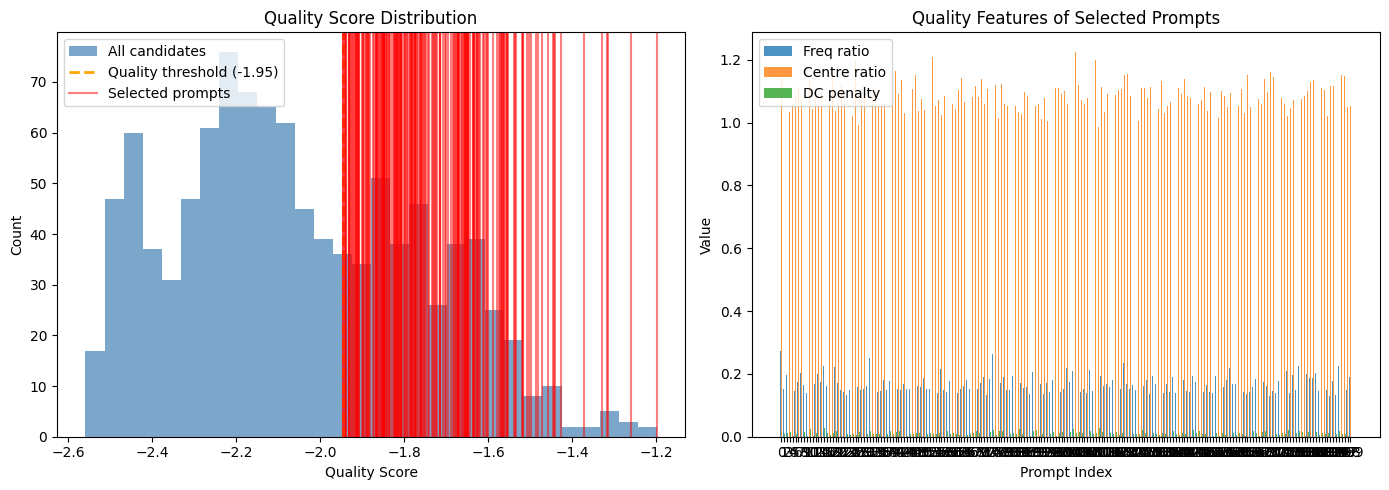


Selected prompts quality statistics:
  Quality score: mean=-1.728, std=0.151, range=[-1.946, -1.198]
  Freq ratio:    mean=0.168, range=[0.128, 0.273]
  Centre ratio:  mean=1.086, range=[0.983, 1.226]
  DC penalty:    mean=0.0110, range=[0.0008, 0.0331]


In [9]:
# Visualize quality score distribution and selection
print("=" * 70)
print("QUALITY SCORE DISTRIBUTION")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram of quality scores
ax1 = axes[0]
all_scores = quality_info['all_scores']
valid_scores = all_scores[~np.isnan(all_scores)]
selected_scores = df_selected['quality_score'].values

ax1.hist(valid_scores, bins=30, alpha=0.7, label='All candidates', color='steelblue')
ax1.axvline(quality_info['threshold'], color='orange', linestyle='--', linewidth=2, 
            label=f'Quality threshold ({quality_info["threshold"]:.2f})')
for i, score in enumerate(selected_scores):
    label = 'Selected prompts' if i == 0 else None
    ax1.axvline(score, color='red', alpha=0.5, linewidth=1.5, label=label)

ax1.set_xlabel('Quality Score')
ax1.set_ylabel('Count')
ax1.set_title('Quality Score Distribution')
ax1.legend()

# Plot 2: Quality features of selected prompts
ax2 = axes[1]
selected_features = quality_info['selected_features']
freq_ratios = [f['freq_ratio'] for f in selected_features]
centre_ratios = [f['centre_ratio'] for f in selected_features]
dc_penalties = [f['dc_penalty'] for f in selected_features]

x = np.arange(len(selected_features))
width = 0.25

bars1 = ax2.bar(x - width, freq_ratios, width, label='Freq ratio', alpha=0.8)
bars2 = ax2.bar(x, centre_ratios, width, label='Centre ratio', alpha=0.8)
bars3 = ax2.bar(x + width, dc_penalties, width, label='DC penalty', alpha=0.8)

ax2.set_xlabel('Prompt Index')
ax2.set_ylabel('Value')
ax2.set_title('Quality Features of Selected Prompts')
ax2.set_xticks(x)
ax2.legend()

plt.tight_layout()
plt.savefig(str(EXP4_RESULTS_DIR / 'quality_score_distribution.png'), dpi=150)
plt.show()

# Print summary statistics
print(f"\nSelected prompts quality statistics:")
print(f"  Quality score: mean={np.mean(selected_scores):.3f}, "
      f"std={np.std(selected_scores):.3f}, "
      f"range=[{np.min(selected_scores):.3f}, {np.max(selected_scores):.3f}]")
print(f"  Freq ratio:    mean={np.mean(freq_ratios):.3f}, range=[{np.min(freq_ratios):.3f}, {np.max(freq_ratios):.3f}]")
print(f"  Centre ratio:  mean={np.mean(centre_ratios):.3f}, range=[{np.min(centre_ratios):.3f}, {np.max(centre_ratios):.3f}]")
print(f"  DC penalty:    mean={np.mean(dc_penalties):.4f}, range=[{np.min(dc_penalties):.4f}, {np.max(dc_penalties):.4f}]")

In [ ]:
# Visualise raw SO(3) and symmetry-aware SO(3)/C2 distances between selected particles
print("=" * 70)
print("ROTATION DISTANCE MATRICES")
print("=" * 70)
print("Assumption: the local z axis is the thyroglobulin C2 symmetry axis")

quats_selected = df_selected[['Q1', 'Q2', 'Q3', 'Q4']].values
n_selected = len(quats_selected)

raw_dist_matrix = np.zeros((n_selected, n_selected))
c2_dist_matrix = np.zeros((n_selected, n_selected))

for i in range(n_selected):
    for j in range(n_selected):
        raw_dist_matrix[i, j] = quaternion_angular_distance_so3(quats_selected[i], quats_selected[j])
        c2_dist_matrix[i, j] = quaternion_angular_distance_c2(quats_selected[i], quats_selected[j])

compression_matrix = raw_dist_matrix - c2_dist_matrix

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im0 = axes[0].imshow(raw_dist_matrix, cmap='viridis', vmin=0, vmax=180)
plt.colorbar(im0, ax=axes[0], label='Distance (deg)')
axes[0].set_xlabel('Prompt Index')
axes[0].set_ylabel('Prompt Index')
axes[0].set_title('Raw SO(3) pairwise distance')
axes[0].set_xticks(range(n_selected))
axes[0].set_yticks(range(n_selected))

im1 = axes[1].imshow(c2_dist_matrix, cmap='viridis', vmin=0, vmax=180)
plt.colorbar(im1, ax=axes[1], label='Distance (deg)')
axes[1].set_xlabel('Prompt Index')
axes[1].set_ylabel('Prompt Index')
axes[1].set_title('Symmetry-aware SO(3)/C2 pairwise distance')
axes[1].set_xticks(range(n_selected))
axes[1].set_yticks(range(n_selected))

plt.tight_layout()
plt.savefig(str(EXP4_RESULTS_DIR / 'angular_distance_matrices_so3_vs_c2.png'), dpi=150)
plt.show()

raw_upper = raw_dist_matrix[np.triu_indices(n_selected, k=1)]
c2_upper = c2_dist_matrix[np.triu_indices(n_selected, k=1)]
compression_upper = compression_matrix[np.triu_indices(n_selected, k=1)]

print("\nRaw SO(3) distance statistics:")
print(f"  Min: {raw_upper.min():.1f} deg")
print(f"  Max: {raw_upper.max():.1f} deg")
print(f"  Mean: {raw_upper.mean():.1f} deg")
print(f"  Std: {raw_upper.std():.1f} deg")

print("\nSymmetry-aware SO(3)/C2 distance statistics:")
print(f"  Min: {c2_upper.min():.1f} deg")
print(f"  Max: {c2_upper.max():.1f} deg")
print(f"  Mean: {c2_upper.mean():.1f} deg")
print(f"  Std: {c2_upper.std():.1f} deg")

print("\nCompression induced by quotienting with C2:")
print(f"  Mean raw - C2 distance: {compression_upper.mean():.1f} deg")
print(f"  Max raw - C2 distance: {compression_upper.max():.1f} deg")


## Step 3: Extract Subtomograms and Generate Prompt Embeddings

In [11]:
print("=" * 70)
print("EXTRACTING SUBTOMOGRAMS FOR SELECTED PROMPTS")
print("=" * 70)

def extract_subtomogram(tomo, x, y, z, patch_size=37):
    """Extract a subtomogram centered at (x, y, z)."""
    half = patch_size // 2
    x, y, z = int(x), int(y), int(z)
    
    # tomo is (Z, Y, X) but coords are (X, Y, Z)
    subtomo = tomo[z-half:z+half+1, y-half:y+half+1, x-half:x+half+1]
    
    if subtomo.shape != (patch_size, patch_size, patch_size):
        return None
    
    return subtomo

# Extract subtomograms
subtomos = []
prompt_info = []

# Cache loaded tomograms
tomo_cache = {}

for idx, row in df_selected.iterrows():
    tomo_name = row['tomo_name']
    # Use voxel coordinates (converted from Angstroms in previous step)
    x, y, z = row['X_voxel'], row['Y_voxel'], row['Z_voxel']
    
    # Load tomogram if not cached
    if tomo_name not in tomo_cache:
        tomo_path = UMU_SYNTH_TOMOS_DIR / f"{tomo_name}.mrc"
        if tomo_path.exists():
            print(f"  Loading {tomo_name}...")
            tomo_cache[tomo_name] = load_mrc_data(str(tomo_path)).float()
        else:
            print(f"  ERROR: Tomogram not found: {tomo_path}")
            continue
    
    tomo = tomo_cache[tomo_name]
    subtomo = extract_subtomogram(tomo, x, y, z, PROMPT_SIZE)
    
    if subtomo is not None:
        subtomos.append(subtomo)
        prompt_info.append({
            'tomo_name': tomo_name,
            'x': x, 'y': y, 'z': z,
            'q1': row['Q1'], 'q2': row['Q2'], 'q3': row['Q3'], 'q4': row['Q4']
        })
        print(f"   Extracted prompt {len(subtomos)} from {tomo_name} at ({x:.0f}, {y:.0f}, {z:.0f})")
    else:
        print(f"  ERROR: Failed to extract from {tomo_name} at ({x:.0f}, {y:.0f}, {z:.0f})")

# Clear cache
del tomo_cache

print(f"\n Extracted {len(subtomos)} subtomograms")

EXTRACTING SUBTOMOGRAMS FOR SELECTED PROMPTS
  Loading tomo_rec_4_snr1.85...
  ✅ Extracted prompt 1 from tomo_rec_4_snr1.85 at (458, 519, 55)
  Loading tomo_rec_11_snr1.41...
  ✅ Extracted prompt 2 from tomo_rec_11_snr1.41 at (173, 338, 101)
  Loading tomo_rec_19_snr1.62...
  ✅ Extracted prompt 3 from tomo_rec_19_snr1.62 at (316, 440, 72)
  ✅ Extracted prompt 4 from tomo_rec_4_snr1.85 at (246, 383, 78)
  ✅ Extracted prompt 5 from tomo_rec_19_snr1.62 at (287, 309, 66)
  ✅ Extracted prompt 6 from tomo_rec_11_snr1.41 at (351, 557, 59)
  ✅ Extracted prompt 7 from tomo_rec_19_snr1.62 at (62, 379, 130)
  Loading tomo_rec_0_snr1.63...
  ✅ Extracted prompt 8 from tomo_rec_0_snr1.63 at (394, 532, 58)
  ✅ Extracted prompt 9 from tomo_rec_11_snr1.41 at (235, 68, 118)
  ✅ Extracted prompt 10 from tomo_rec_11_snr1.41 at (137, 481, 77)
  ✅ Extracted prompt 11 from tomo_rec_19_snr1.62 at (295, 516, 103)
  Loading tomo_rec_12_snr1.39...
  ✅ Extracted prompt 12 from tomo_rec_12_snr1.39 at (570, 86, 58)

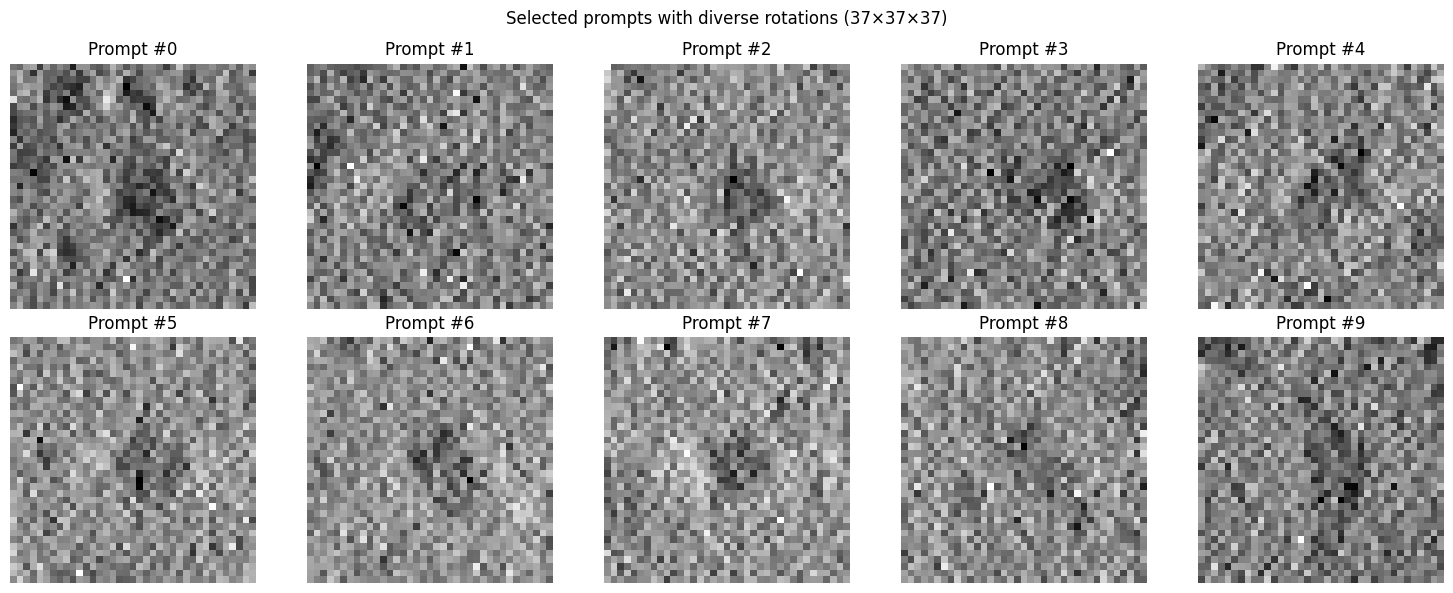

In [12]:
# Visualize extracted subtomograms
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    if i < len(subtomos):
        subtomo = subtomos[i]
        if isinstance(subtomo, torch.Tensor):
            subtomo = subtomo.numpy()
        central_slice = subtomo[PROMPT_SIZE // 2]
        ax.imshow(central_slice, cmap='gray')
        ax.set_title(f"Prompt #{i}")
    ax.axis('off')

plt.suptitle(f"Selected prompts with diverse rotations ({PROMPT_SIZE}x{PROMPT_SIZE}x{PROMPT_SIZE})")
plt.tight_layout()
plt.savefig(str(EXP4_RESULTS_DIR / 'selected_prompts_visualization.png'), dpi=150)
plt.show()

In [13]:
print("=" * 70)
print("GENERATING PROMPT EMBEDDINGS WITH TOMOTWIN")
print("=" * 70)

# Convert to tensor
subtomos_tensor = torch.stack([
    torch.tensor(s) if not isinstance(s, torch.Tensor) else s 
    for s in subtomos
])

print(f"Input shape: {subtomos_tensor.shape}")

# Generate embeddings
embeddings = pass_subtomos_through_tomotwin(
    subtomos_tensor, 
    str(TOMOTWIN_MODEL_FILE)
)

print(f"Embeddings shape: {embeddings.shape}")
print(f"Embedding dimension: {embeddings.shape[1]}")

GENERATING PROMPT EMBEDDINGS WITH TOMOTWIN
Input shape: torch.Size([200, 37, 37, 37])


Passing subtomos through TomoTwin: 100%|█████████████████████| 7/7 [00:07<00:00,  1.14s/it]

Embeddings shape: torch.Size([200, 32])
Embedding dimension: 32


In [14]:
# Save individual prompt embeddings as JSON files
print("=" * 70)
print("SAVING PROMPT EMBEDDINGS")
print("=" * 70)

for i in range(len(embeddings)):
    prompt_data = {
        THYROGLOBULIN_NAME: embeddings[i].tolist(),
        "metadata": {
            "prompt_index": i,
            "tomo_name": prompt_info[i]['tomo_name'],
            "coords": [prompt_info[i]['x'], prompt_info[i]['y'], prompt_info[i]['z']],
            "quaternion": [
                prompt_info[i]['q1'], prompt_info[i]['q2'],
                prompt_info[i]['q3'], prompt_info[i]['q4']
            ]
        }
    }
    
    prompt_file = EXP4_PROMPTS_DIR / f"prompt_{i:02d}.json"
    with open(prompt_file, 'w') as f:
        json.dump(prompt_data, f, indent=2)
    
    print(f"   Saved: {prompt_file.name}")

# Also save combined file with all embeddings
all_prompts = {
    "prompts": [
        {
            "index": i,
            "embedding": embeddings[i].tolist(),
            "metadata": prompt_info[i]
        }
        for i in range(len(embeddings))
    ]
}

all_prompts_file = EXP4_PROMPTS_DIR / "all_rotation_prompts.json"
with open(all_prompts_file, 'w') as f:
    json.dump(all_prompts, f, indent=2)

print(f"\n Saved combined prompts to: {all_prompts_file}")

SAVING PROMPT EMBEDDINGS
  ✅ Saved: prompt_00.json
  ✅ Saved: prompt_01.json
  ✅ Saved: prompt_02.json
  ✅ Saved: prompt_03.json
  ✅ Saved: prompt_04.json
  ✅ Saved: prompt_05.json
  ✅ Saved: prompt_06.json
  ✅ Saved: prompt_07.json
  ✅ Saved: prompt_08.json
  ✅ Saved: prompt_09.json
  ✅ Saved: prompt_10.json
  ✅ Saved: prompt_11.json
  ✅ Saved: prompt_12.json
  ✅ Saved: prompt_13.json
  ✅ Saved: prompt_14.json
  ✅ Saved: prompt_15.json
  ✅ Saved: prompt_16.json
  ✅ Saved: prompt_17.json
  ✅ Saved: prompt_18.json
  ✅ Saved: prompt_19.json
  ✅ Saved: prompt_20.json
  ✅ Saved: prompt_21.json
  ✅ Saved: prompt_22.json
  ✅ Saved: prompt_23.json
  ✅ Saved: prompt_24.json
  ✅ Saved: prompt_25.json
  ✅ Saved: prompt_26.json
  ✅ Saved: prompt_27.json
  ✅ Saved: prompt_28.json
  ✅ Saved: prompt_29.json
  ✅ Saved: prompt_30.json
  ✅ Saved: prompt_31.json
  ✅ Saved: prompt_32.json
  ✅ Saved: prompt_33.json
  ✅ Saved: prompt_34.json
  ✅ Saved: prompt_35.json
  ✅ Saved: prompt_36.json
  ✅ Saved: pr

## Step 4: Copy Ground Truth Coordinates

Copy ground truth coordinates from EXP3 for evaluation.

In [15]:
import shutil

print("=" * 70)
print("COPYING GROUND TRUTH COORDINATES")
print("=" * 70)

for tomo_name in EXP4_VAL_TOMOS:
    src_file = EXP3_COORDS_DIR / f"{tomo_name}_thyroglobulin_coords.csv"
    dst_file = EXP4_COORDS_DIR / f"{tomo_name}_thyroglobulin_coords.csv"
    
    if src_file.exists():
        shutil.copy(src_file, dst_file)
        df_gt = pd.read_csv(src_file)
        print(f"   {tomo_name}: {len(df_gt)} particles")
    else:
        print(f"  ERROR: {tomo_name}: source file not found")

print(f"\n Ground truth coordinates copied to: {EXP4_COORDS_DIR}")

COPYING GROUND TRUTH COORDINATES
  ✅ tomo_rec_5_snr1.66: 127 particles
  ✅ tomo_rec_6_snr1.17: 120 particles
  ✅ tomo_rec_7_snr1.13: 133 particles
  ✅ tomo_rec_8_snr0.57: 115 particles
  ✅ tomo_rec_9_snr1.28: 127 particles

✅ Ground truth coordinates copied to: /media/Disco_12TB/cryoet-particle-picking-results/exp4_ppicker_rotations/large_prompt_population_200/coords


## Step 5: Run Inference

Run inference using the generated prompts. This can be done either:
1. From the command line using the inference script
2. Programmatically from this notebook

The inference script will run for Multi-prompt fine-tuned model (increment 16)

In [16]:
# Display command to run inference
print("=" * 70)
print("INFERENCE COMMAND")
print("=" * 70)

inference_script = PROJECT_ROOT / "experiments" / "exp4_ppicker_rotations" / "scripts" / "umusynth_inference_large.py"

print(f"\nTo run inference, execute the following commands:")
print(f"\n  cd {PROJECT_ROOT / 'tools' / 'ProPicker'}")
print(f"  conda activate deepetpicker")
print(f"\n  # Run all inferences over the study subset (first {EXP4_STUDY_NUM_PROMPTS} prompts from the {EXP4_TARGET_NUM_PROMPTS}-prompt population):")
print(f"  python ../../experiments/exp4_ppicker_rotations/scripts/umusynth_inference_large.py --run-name {EXP4_RUN_NAME} --num-prompts {EXP4_STUDY_NUM_PROMPTS}")
print(f"\n  # Or run specific configurations:")
print(f"  python ../../experiments/exp4_ppicker_rotations/scripts/umusynth_inference_large.py --run-name {EXP4_RUN_NAME} --checkpoint-type base --num-prompts {EXP4_STUDY_NUM_PROMPTS}")
print(f"  python ../../experiments/exp4_ppicker_rotations/scripts/umusynth_inference_large.py --run-name {EXP4_RUN_NAME} --checkpoint-type single --increment 8 --num-prompts {EXP4_STUDY_NUM_PROMPTS}")
print(f"  python ../../experiments/exp4_ppicker_rotations/scripts/umusynth_inference_large.py --run-name {EXP4_RUN_NAME} --checkpoint-type multi --increment 8 --num-prompts {EXP4_STUDY_NUM_PROMPTS}")

INFERENCE COMMAND

To run inference, execute the following commands:

  cd /home/carloshg/Dev/cryoet-particle-picking/tools/ProPicker
  conda activate deepetpicker

  # Run all inferences (base + all increments × first 200 prompts):
  python ../../experiments/exp4_ppicker_rotations/scripts/umusynth_inference_large.py --run-name large_prompt_population_200 --num-prompts 200

  # Or run specific configurations:
  python ../../experiments/exp4_ppicker_rotations/scripts/umusynth_inference_large.py --run-name large_prompt_population_200 --checkpoint-type base --num-prompts 200
  python ../../experiments/exp4_ppicker_rotations/scripts/umusynth_inference_large.py --run-name large_prompt_population_200 --checkpoint-type single --increment 8 --num-prompts 200
  python ../../experiments/exp4_ppicker_rotations/scripts/umusynth_inference_large.py --run-name large_prompt_population_200 --checkpoint-type multi --increment 8 --num-prompts 200


### Optional: Load an Existing Run for Analysis

If prompt selection and embedding generation were already executed in a previous run, this block lets the notebook analyze that saved run directly. It reloads the prompt bundle from disk and re-extracts the prompt subtomograms from the tomograms, so Step 7 does not depend on the in-memory variables created by Steps 2 and 3.

In [2]:
print("=" * 70)
print("ANALYSIS RUN SELECTION")
print("=" * 70)

import json
import numpy as np
import pandas as pd

if 'load_mrc_data' not in globals():
    from utils.mrctools import load_mrc_data

# Change this to analyze an existing saved run instead of the current session run.
# Example: EXP4_ANALYSIS_RUN_NAME = "large_prompt_population_200"
EXP4_ANALYSIS_RUN_NAME = EXP4_RUN_NAME

EXP4_ANALYSIS_RESULTS_DIR = EXP4_BASE_RESULTS_DIR / EXP4_ANALYSIS_RUN_NAME
EXP4_ANALYSIS_PROMPTS_DIR = EXP4_ANALYSIS_RESULTS_DIR / "prompts"
EXP4_ANALYSIS_INFERENCE_DIR = EXP4_ANALYSIS_RESULTS_DIR / "inference"
EXP4_ANALYSIS_COORDS_DIR = EXP4_ANALYSIS_RESULTS_DIR / "coords"

print(f"Analysis run: {EXP4_ANALYSIS_RUN_NAME}")
print(f"  Results dir:   {EXP4_ANALYSIS_RESULTS_DIR}")
print(f"  Prompts dir:   {EXP4_ANALYSIS_PROMPTS_DIR}")
print(f"  Inference dir: {EXP4_ANALYSIS_INFERENCE_DIR}")
print(f"  Coords dir:    {EXP4_ANALYSIS_COORDS_DIR}")

analysis_df_selected = None
analysis_prompt_info = None
analysis_subtomos = None
analysis_embeddings = None

reuse_in_memory_assets = (
    EXP4_ANALYSIS_RUN_NAME == EXP4_RUN_NAME
    and 'df_selected' in globals()
    and 'prompt_info' in globals()
    and 'subtomos' in globals()
    and 'embeddings' in globals()
)

if reuse_in_memory_assets:
    analysis_df_selected = df_selected.copy()
    analysis_prompt_info = list(prompt_info)
    analysis_subtomos = list(subtomos)
    analysis_embeddings = embeddings
    print("Using in-memory prompt assets from Steps 2 and 3")
else:
    print("Loading prompt assets from disk")
    all_prompts_file = EXP4_ANALYSIS_PROMPTS_DIR / "all_rotation_prompts.json"

    if not all_prompts_file.exists():
        print(f"Prompt bundle not found: {all_prompts_file}")
    else:
        with open(all_prompts_file, 'r') as f:
            prompt_bundle = json.load(f)

        prompt_records = sorted(prompt_bundle['prompts'], key=lambda r: int(r['index']))
        print(f"  Prompt records found: {len(prompt_records)}")

        if 'extract_subtomogram' not in globals():
            def extract_subtomogram(tomo, x, y, z, patch_size=37):
                half = patch_size // 2
                x, y, z = int(x), int(y), int(z)
                subtomo = tomo[z-half:z+half+1, y-half:y+half+1, x-half:x+half+1]
                if subtomo.shape != (patch_size, patch_size, patch_size):
                    return None
                return subtomo

        analysis_rows = []
        analysis_prompt_info = []
        analysis_embedding_list = []
        analysis_subtomos = []
        tomo_cache = {}

        for record in prompt_records:
            meta = record['metadata']
            prompt_idx = int(record['index'])

            if 'coords' in meta:
                x, y, z = meta['coords']
            else:
                x, y, z = meta['x'], meta['y'], meta['z']

            if 'quaternion' in meta:
                q1, q2, q3, q4 = meta['quaternion']
            else:
                q1, q2, q3, q4 = meta['q1'], meta['q2'], meta['q3'], meta['q4']

            tomo_name = meta['tomo_name']

            analysis_rows.append({
                'prompt_idx': prompt_idx,
                'tomo_name': tomo_name,
                'x': float(x),
                'y': float(y),
                'z': float(z),
                'q1': float(q1),
                'q2': float(q2),
                'q3': float(q3),
                'q4': float(q4),
            })
            analysis_prompt_info.append({
                'tomo_name': tomo_name,
                'x': float(x),
                'y': float(y),
                'z': float(z),
                'q1': float(q1),
                'q2': float(q2),
                'q3': float(q3),
                'q4': float(q4),
            })
            analysis_embedding_list.append(record['embedding'])

        analysis_df_selected = pd.DataFrame(analysis_rows).sort_values('prompt_idx').reset_index(drop=True)
        analysis_embeddings = np.asarray(analysis_embedding_list, dtype=np.float32)

        for row in analysis_df_selected.itertuples(index=False):
            tomo_name = row.tomo_name
            if tomo_name not in tomo_cache:
                tomo_path = UMU_SYNTH_TOMOS_DIR / f"{tomo_name}.mrc"
                if not tomo_path.exists():
                    raise FileNotFoundError(f"Tomogram not found: {tomo_path}")
                print(f"  Loading {tomo_name}...")
                tomo_cache[tomo_name] = load_mrc_data(str(tomo_path)).float()

            subtomo = extract_subtomogram(tomo_cache[tomo_name], row.x, row.y, row.z, PROMPT_SIZE)
            if subtomo is None:
                raise ValueError(
                    f"Failed to extract prompt {row.prompt_idx} from {tomo_name} at ({row.x}, {row.y}, {row.z})"
                )
            analysis_subtomos.append(subtomo)

        print(f"  Loaded embeddings: {analysis_embeddings.shape}")
        print(f"  Re-extracted subtomograms: {len(analysis_subtomos)}")

if analysis_prompt_info is not None:
    print(f"Prompt assets ready for analysis: {len(analysis_prompt_info)} prompts")
else:
    print("Prompt assets are not available yet")

ANALYSIS RUN SELECTION
Analysis run: large_prompt_population_125
  Results dir:   /media/Disco_12TB/cryoet-particle-picking-results/exp4_ppicker_rotations/large_prompt_population_125
  Prompts dir:   /media/Disco_12TB/cryoet-particle-picking-results/exp4_ppicker_rotations/large_prompt_population_125/prompts
  Inference dir: /media/Disco_12TB/cryoet-particle-picking-results/exp4_ppicker_rotations/large_prompt_population_125/inference
  Coords dir:    /media/Disco_12TB/cryoet-particle-picking-results/exp4_ppicker_rotations/large_prompt_population_125/coords
Loading prompt assets from disk
  Prompt records found: 126
  Loading tomo_rec_4_snr1.85...
  Loading tomo_rec_11_snr1.41...
  Loading tomo_rec_19_snr1.62...
  Loading tomo_rec_0_snr1.63...
  Loading tomo_rec_12_snr1.39...
  Loading tomo_rec_1_snr1.46...
  Loading tomo_rec_24_snr1.39...
  Loading tomo_rec_13_snr1.1...
  Loaded embeddings: (126, 32)
  Re-extracted subtomograms: 126
Prompt assets ready for analysis: 126 prompts


## Step 6: Load and Analyze Results

After running inference, analyze the results to compare performance across prompts and checkpoints.

In [3]:
import glob

print("=" * 70)
print("LOADING INFERENCE RESULTS")
print("=" * 70)

# Check for inference results in the active analysis run
inference_dir = EXP4_ANALYSIS_INFERENCE_DIR

if not inference_dir.exists():
    print(f"Inference directory not found: {inference_dir}")
    print("   Run the inference script first.")
else:
    print(f"Using run: {EXP4_ANALYSIS_RUN_NAME}")
    result_dirs = sorted(inference_dir.glob("*"))
    print(f"Found {len(result_dirs)} inference results:")
    for d in result_dirs:
        if d.is_dir():
            coords_dir = d / "PredictedLabels" / "Coords_All"
            if coords_dir.exists():
                n_files = len(list(coords_dir.glob("*.coords")))
                print(f"  OK {d.name}: {n_files} coordinate files")
            else:
                print(f"  Pending {d.name}: no coordinates yet")

LOADING INFERENCE RESULTS
Using run: large_prompt_population_125
Found 126 inference results:
  OK multi_inc16_prompt0: 5 coordinate files
  OK multi_inc16_prompt1: 5 coordinate files
  OK multi_inc16_prompt10: 5 coordinate files
  OK multi_inc16_prompt100: 5 coordinate files
  OK multi_inc16_prompt101: 5 coordinate files
  OK multi_inc16_prompt102: 5 coordinate files
  OK multi_inc16_prompt103: 5 coordinate files
  OK multi_inc16_prompt104: 5 coordinate files
  OK multi_inc16_prompt105: 5 coordinate files
  OK multi_inc16_prompt106: 5 coordinate files
  OK multi_inc16_prompt107: 5 coordinate files
  OK multi_inc16_prompt108: 5 coordinate files
  OK multi_inc16_prompt109: 5 coordinate files
  OK multi_inc16_prompt11: 5 coordinate files
  OK multi_inc16_prompt110: 5 coordinate files
  OK multi_inc16_prompt111: 5 coordinate files
  OK multi_inc16_prompt112: 5 coordinate files
  OK multi_inc16_prompt113: 5 coordinate files
  OK multi_inc16_prompt114: 5 coordinate files
  OK multi_inc16_pr

In [4]:
EXP4_MATCHING_DISTANCE_THRESHOLD = 15.0
EXP4_MATCHING_STRATEGY = "greedy one-to-one assignment"


def compute_metrics(pred_coords, gt_coords, distance_threshold=EXP4_MATCHING_DISTANCE_THRESHOLD):
    """
    Compute precision, recall, and F1 score with a fixed evaluation protocol.

    Important:
        The same matching distance threshold and the same greedy one-to-one
        matching criterion are kept for all analyses. Only the downstream
        summary metric changes from recall-first to F1-first.

    Args:
        pred_coords: Predicted coordinates (N, 3)
        gt_coords: Ground truth coordinates (M, 3)
        distance_threshold: Maximum distance for a match (voxels)

    Returns:
        dict with precision, recall, f1, tp, fp, fn
    """
    if len(pred_coords) == 0:
        return {'precision': 0, 'recall': 0, 'f1': 0, 'tp': 0, 'fp': 0, 'fn': len(gt_coords)}

    if len(gt_coords) == 0:
        return {'precision': 0, 'recall': 0, 'f1': 0, 'tp': 0, 'fp': len(pred_coords), 'fn': 0}

    # Compute distance matrix
    distances = cdist(pred_coords, gt_coords)

    # Match predictions to ground truth using greedy one-to-one assignment
    tp = 0
    matched_gt = set()

    for i in range(len(pred_coords)):
        min_dist = float('inf')
        best_j = -1

        for j in range(len(gt_coords)):
            if j not in matched_gt and distances[i, j] < min_dist:
                min_dist = distances[i, j]
                best_j = j

        if best_j != -1 and min_dist <= distance_threshold:
            tp += 1
            matched_gt.add(best_j)

    fp = len(pred_coords) - tp
    fn = len(gt_coords) - tp

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': tp,
        'fp': fp,
        'fn': fn
    }


def load_predicted_coords(result_dir, tomo_name):
    """
    Load predicted coordinates from a result directory.
    .coords files are tab-separated with columns: class_id, x, y, z (no headers)
    """
    # .coords files are named {tomo_name}.coords (without thyroglobulin suffix)
    coords_file = result_dir / "PredictedLabels" / "Coords_All" / f"{tomo_name}.coords"

    if coords_file.exists():
        # Read tab-separated file without headers: class_id, x, y, z
        df = pd.read_csv(coords_file, sep='\t', header=None, names=['class_id', 'x', 'y', 'z'])
        return df[['x', 'y', 'z']].values

    return np.array([]).reshape(0, 3)


def load_gt_coords(tomo_name):
    """Load ground truth coordinates."""
    coords_file = EXP4_ANALYSIS_COORDS_DIR / f"{tomo_name}_thyroglobulin_coords.csv"

    if coords_file.exists():
        df = pd.read_csv(coords_file)
        return df[['X', 'Y', 'Z']].values

    return np.array([]).reshape(0, 3)


In [5]:
print("=" * 70)
print("COMPUTING METRICS FOR ALL RESULTS")
print("=" * 70)

print("Evaluation protocol:")
print(f"  Matching threshold: {EXP4_MATCHING_DISTANCE_THRESHOLD:.1f} voxels")
print(f"  Matching strategy: {EXP4_MATCHING_STRATEGY}")
print("  This protocol is kept fixed so F1 remains directly comparable to recall.")

all_results = []

inference_dir = EXP4_ANALYSIS_INFERENCE_DIR

if inference_dir.exists():
    for result_dir in sorted(inference_dir.glob("*")):
        if not result_dir.is_dir():
            continue
        
        # Parse result name: base_promptX or {single,multi}_incY_promptX
        name = result_dir.name
        
        if name.startswith("base_"):
            checkpoint_type = "base"
            increment = 0
            prompt_idx = int(name.split("prompt")[1])
        else:
            parts = name.split("_")
            checkpoint_type = parts[0]
            increment = int(parts[1].replace("inc", ""))
            prompt_idx = int(parts[2].replace("prompt", ""))
        
        # Compute metrics for each validation tomogram
        for tomo_name in EXP4_VAL_TOMOS:
            pred_coords = load_predicted_coords(result_dir, tomo_name)
            gt_coords = load_gt_coords(tomo_name)
            
            if len(gt_coords) == 0:
                continue
            
            metrics = compute_metrics(
                pred_coords,
                gt_coords,
                distance_threshold=EXP4_MATCHING_DISTANCE_THRESHOLD,
            )
            
            all_results.append({
                'checkpoint_type': checkpoint_type,
                'increment': increment,
                'prompt_idx': prompt_idx,
                'tomo_name': tomo_name,
                **metrics
            })

if all_results:
    df_results_all = pd.DataFrame(all_results)
    df_results = df_results_all[df_results_all['prompt_idx'] < EXP4_STUDY_NUM_PROMPTS].copy()
    print(f"\nComputed metrics for {len(df_results_all)} tomogram-level rows")
    print(
        f"Using study subset: prompt_idx 0..{EXP4_STUDY_NUM_PROMPTS - 1} "
        f"({df_results['prompt_idx'].nunique()} prompts)"
    )
    df_results.head(10)
else:
    print("No results found. Run inference first.")
    df_results = pd.DataFrame()

COMPUTING METRICS FOR ALL RESULTS
Evaluation protocol:
  Matching threshold: 15.0 voxels
  Matching strategy: greedy one-to-one assignment
  This protocol is kept fixed so F1 remains directly comparable to recall.

Computed metrics for 630 tomogram-level rows
Using study subset: prompt_idx 0..124 (125 prompts)


In [6]:
# Skip analysis if no results
if len(df_results) == 0:
    print("Skipping analysis - run inference first")
else:
    # Aggregate metrics per checkpoint type and prompt
    print("=" * 70)
    print("AGGREGATED RESULTS")
    print("=" * 70)
    
    print(
        f"\nAnalyzing study subset: prompt_idx 0..{EXP4_STUDY_NUM_PROMPTS - 1}"
    )
    
    # Group by checkpoint type and prompt
    df_agg = df_results.groupby(['checkpoint_type', 'increment', 'prompt_idx']).agg({
        'precision': ['mean', 'std'],
        'recall': ['mean', 'std'],
        'f1': ['mean', 'std'],
        'tp': 'sum',
        'fp': 'sum',
        'fn': 'sum'
    }).round(3)
    
    print("\nMetrics per checkpoint and prompt:")
    display(df_agg)

AGGREGATED RESULTS

Analyzing study subset: prompt_idx 0..124

Metrics per checkpoint and prompt:


precision        recall            f1  \
                                          mean    std   mean    std   mean   
checkpoint_type increment prompt_idx                                         
multi           16        0              0.944  0.072  0.802  0.097  0.867   
                          1              0.964  0.038  0.437  0.073  0.599   
                          2              0.839  0.117  0.936  0.062  0.884   
                          3              0.980  0.015  0.504  0.054  0.664   
                          4              0.847  0.126  0.982  0.020  0.906   
...                                        ...    ...    ...    ...    ...   
                          120            0.901  0.095  0.927  0.059  0.913   
                          121            0.878  0.083  0.950  0.047  0.912   
                          122            0.945  0.059  0.842  0.089  0.890   
                          123            0.951  0.038  0.844  0.105  0.893   
                          124            1.000  0.000  0.115  0.031  0.206   

                                              tp   fp   fn  
                                        std  sum  sum  sum  
checkpoint_type increment prompt_idx                        
multi           16        0           0.086  501   27  121  
                          1           0.078  273    9  349  
                          2           0.093  584  116   38  
                          3           0.045  315    7  307  
                          4           0.087  611  120   11  
...                                     ...  ...  ...  ...  
                          120         0.078  578   64   44  
                          121         0.067  592   83   30  
                          122         0.072  526   29   96  
                          123         0.077  527   25   95  
                          124         0.049   71    0  551  

[125 rows x 9 columns]

In [7]:
# Análisis detallado de resultados para multi_inc16
print("=" * 70)
print("RESULTADOS DE INFERENCIA: MULTI_INC16")
print("=" * 70)

if len(df_results) > 0:
    # Filtrar solo los resultados de multi_inc16 dentro del subconjunto de estudio
    df_multi16 = df_results[
        (df_results['checkpoint_type'] == 'multi')
        & (df_results['increment'] == 16)
        & (df_results['prompt_idx'] < EXP4_STUDY_NUM_PROMPTS)
    ].copy()
    
    if len(df_multi16) > 0:
        # Crear tabla pivote: F1 por tomograma y prompt
        pivot_f1 = df_multi16.pivot_table(
            values='f1', 
            index='tomo_name', 
            columns='prompt_idx',
            aggfunc='first'
        ).round(3)
        
        print("\nF1 Score por tomograma y prompt (multi_inc16):\n")
        display(pivot_f1)

        pivot_p = df_multi16.pivot_table(
            values='precision', 
            index='tomo_name', 
            columns='prompt_idx',
            aggfunc='first'
        ).round(3)

        pivot_rc = df_multi16.pivot_table(
            values='recall', 
            index='tomo_name', 
            columns='prompt_idx',
            aggfunc='first'
        ).round(3)

        display(pivot_p)
        display(pivot_rc)
        
        # Estadísticas por tomograma
        print("\nEstadísticas por tomograma:")
        stats_per_tomo = df_multi16.groupby('tomo_name').agg({
            'f1': ['mean', 'std', 'min', 'max'],
            'precision': 'mean',
            'recall': 'mean'
        }).round(3)
        stats_per_tomo.columns = ['F1 Mean', 'F1 Std', 'F1 Min', 'F1 Max', 'Precision Mean', 'Recall Mean']
        display(stats_per_tomo)
        
        # Estadísticas por prompt
        print("\nEstadísticas por prompt:")
        stats_per_prompt = df_multi16.groupby('prompt_idx').agg({
            'f1': ['mean', 'std'],
            'precision': 'mean',
            'recall': 'mean'
        }).round(3)
        stats_per_prompt.columns = ['F1 Mean', 'F1 Std', 'Precision Mean', 'Recall Mean']
        display(stats_per_prompt)
        
        # Resumen general
        print(f"\nResumen general multi_inc16:")
        print(f"   - F1 promedio global: {df_multi16['f1'].mean():.3f} ± {df_multi16['f1'].std():.3f}")
        print(f"   - Precision promedio: {df_multi16['precision'].mean():.3f}")
        print(f"   - Recall promedio: {df_multi16['recall'].mean():.3f}")
        print(f"   - Mejor F1: {df_multi16['f1'].max():.3f} (prompt {df_multi16.loc[df_multi16['f1'].idxmax(), 'prompt_idx']}, tomo {df_multi16.loc[df_multi16['f1'].idxmax(), 'tomo_name']})")
    else:
        print("No se encontraron resultados para multi_inc16")
else:
    print("No hay resultados disponibles - ejecutar inferencia primero")

RESULTADOS DE INFERENCIA: MULTI_INC16

F1 Score por tomograma y prompt (multi_inc16):



prompt_idx,0,1,2,3,4,5,6,7,8,9,...,115,116,117,118,119,120,121,122,123,124
tomo_name,,,,,,,,,,,,,,,,,,,,,
tomo_rec_5_snr1.66,0.900,0.663,0.927,0.704,0.958,0.931,0.931,0.957,0.895,0.945,...,0.960,0.941,0.949,0.0,0.955,0.949,0.938,0.933,0.917,0.211
tomo_rec_6_snr1.17,0.884,0.637,0.899,0.670,0.941,0.916,0.928,0.953,0.849,0.955,...,0.962,0.931,0.934,0.0,0.924,0.933,0.935,0.896,0.917,0.182
tomo_rec_7_snr1.13,0.911,0.622,0.929,0.705,0.942,0.952,0.959,0.940,0.913,0.935,...,0.956,0.942,0.946,0.0,0.937,0.959,0.939,0.942,0.929,0.153
tomo_rec_8_snr0.57,0.716,0.465,0.719,0.598,0.752,0.746,0.750,0.780,0.703,0.786,...,0.817,0.762,0.764,0.0,0.747,0.776,0.794,0.766,0.756,0.284
tomo_rec_9_snr1.28,0.922,0.609,0.943,0.646,0.936,0.949,0.949,0.945,0.879,0.946,...,0.946,0.954,0.950,0.0,0.952,0.950,0.954,0.912,0.944,0.199


prompt_idx,0,1,2,3,4,5,6,7,8,9,...,115,116,117,118,119,120,121,122,123,124
tomo_name,,,,,,,,,,,,,,,,,,,,,
tomo_rec_5_snr1.66,1.000,0.970,0.903,0.972,0.920,0.958,0.958,0.960,0.955,0.938,...,0.976,0.938,0.952,0.0,1.000,0.952,0.924,1.000,0.973,1.0
tomo_rec_6_snr1.17,0.952,0.966,0.874,0.984,0.895,0.924,0.948,0.974,0.939,0.943,...,0.983,0.912,0.919,0.0,0.990,0.941,0.913,0.980,0.963,1.0
tomo_rec_7_snr1.13,0.983,1.000,0.879,0.961,0.903,0.935,0.949,0.940,0.959,0.902,...,0.942,0.903,0.910,0.0,0.976,0.949,0.897,0.968,0.975,1.0
tomo_rec_8_snr0.57,0.820,0.900,0.632,1.000,0.623,0.752,0.771,0.825,0.816,0.701,...,0.800,0.683,0.688,0.0,0.892,0.731,0.730,0.851,0.884,1.0
tomo_rec_9_snr1.28,0.966,0.982,0.906,0.984,0.893,0.938,0.938,0.938,0.938,0.925,...,0.931,0.932,0.925,0.0,0.975,0.932,0.926,0.927,0.959,1.0


prompt_idx,0,1,2,3,4,5,6,7,8,9,...,115,116,117,118,119,120,121,122,123,124
tomo_name,,,,,,,,,,,,,,,,,,,,,
tomo_rec_5_snr1.66,0.819,0.504,0.953,0.551,1.000,0.906,0.906,0.953,0.843,0.953,...,0.945,0.945,0.945,0.0,0.913,0.945,0.953,0.874,0.866,0.118
tomo_rec_6_snr1.17,0.825,0.475,0.925,0.508,0.992,0.908,0.908,0.933,0.775,0.967,...,0.942,0.950,0.950,0.0,0.867,0.925,0.958,0.825,0.875,0.100
tomo_rec_7_snr1.13,0.850,0.451,0.985,0.556,0.985,0.970,0.970,0.940,0.872,0.970,...,0.970,0.985,0.985,0.0,0.902,0.970,0.985,0.917,0.887,0.083
tomo_rec_8_snr0.57,0.635,0.313,0.835,0.426,0.948,0.739,0.730,0.739,0.617,0.896,...,0.835,0.861,0.861,0.0,0.643,0.826,0.870,0.696,0.661,0.165
tomo_rec_9_snr1.28,0.882,0.441,0.984,0.480,0.984,0.961,0.961,0.953,0.827,0.969,...,0.961,0.976,0.976,0.0,0.929,0.969,0.984,0.898,0.929,0.110



Estadísticas por tomograma:


,F1 Mean,F1 Std,F1 Min,F1 Max,Precision Mean,Recall Mean
tomo_name,,,,,,
tomo_rec_5_snr1.66,0.815,0.284,0.0,0.976,0.873,0.799
tomo_rec_6_snr1.17,0.801,0.287,0.0,0.983,0.856,0.791
tomo_rec_7_snr1.13,0.811,0.290,0.0,0.962,0.853,0.815
tomo_rec_8_snr0.57,0.659,0.231,0.0,0.826,0.688,0.692
tomo_rec_9_snr1.28,0.812,0.288,0.0,0.966,0.849,0.817



Estadísticas por prompt:


,F1 Mean,F1 Std,Precision Mean,Recall Mean
prompt_idx,,,,
0,0.867,0.086,0.944,0.802
1,0.599,0.078,0.964,0.437
2,0.884,0.093,0.839,0.936
3,0.664,0.045,0.980,0.504
4,0.906,0.087,0.847,0.982
...,...,...,...,...
120,0.913,0.078,0.901,0.927
121,0.912,0.067,0.878,0.950
122,0.890,0.072,0.945,0.842



Resumen general multi_inc16:
   - F1 promedio global: 0.780 ± 0.283
   - Precision promedio: 0.824
   - Recall promedio: 0.783
   - Mejor F1: 0.983 (prompt 80, tomo tomo_rec_6_snr1.17)


## Step 7: Theory-Guided Rotational Issues Analysis (125-prompt study subset)

This section studies only the first `125` prompts (`prompt_idx = 0..124`) and focuses on separating the most plausible cryoET failure modes.

Primary analysis metric:
- mean `F1` across the 5 validation tomograms.

Secondary safeguard metric:
- mean `recall`, so false-negative sensitivity is not hidden by the switch to `F1`.

Evaluation protocol kept fixed:
1. Same predicted coordinate files as before.
2. Same matching distance threshold: `15.0` voxels.
3. Same matching criterion: greedy one-to-one assignment between predictions and ground truth.

Theory-guided explanatory axes:
1. Symmetry-aware orientation analysis in `SO(3)/C2` for thyroglobulin.
2. Orientation relative to the global `Z` axis, as a proxy for acquisition anisotropy and missing-wedge sensitivity.
3. Prompt-source quality, including source tomogram SNR, contrast, frequency content, centering and Fourier anisotropy.
4. Positional effects inside the tomogram, especially `Z` offset and distance to the tomogram center.

Reduced causal protocol added to this step:
1. Adjusted linear models where the main block is `rotation + acquisition anisotropy` and the confounder block contains prompt quality and position terms.
2. The target metric is mean `F1`, with mean `recall` repeated as the secondary safeguard analysis.
3. Source-tomogram fixed effects are included in the adjusted model so source-volume differences are not mistaken for rotation.
4. A tomogram-stratified permutation test checks whether the incremental contribution of the rotation block survives after confounder adjustment.
5. A `C2` consistency check studies whether prompts that are close in `SO(3)/C2` still show large performance gaps.

The analysis below aggregates `multi_inc16` inference metrics across the validation tomograms, derives quaternion-based orientation descriptors beyond raw Euler angles, extracts visual and frequency features from each prompt subtomogram, and then runs correlation analysis, PCA, the adjusted causal checks and the `C2` consistency study with a cryoET-oriented interpretation. All ranking, quartiles and cluster interpretations are now driven by `F1`, while `recall` is retained as the secondary check.


ROTATIONAL ISSUES ANALYSIS
Analysis directory: /media/Disco_12TB/cryoet-particle-picking-results/exp4_ppicker_rotations/large_prompt_population_125/rotational_issues_analysis_125
Prompts analyzed: 125
Focus checkpoint: multi_inc16
Tomogram shapes loaded: 8
Silhouette by k: {2: 0.22545460091464747, 3: 0.12904785662493412, 4: 0.13055618057812185, 5: 0.10617443839149208, 6: 0.11299103625527478}
Cluster feature set: ['c2_axis_to_global_z_deg', 'c2_rotation_nn_deg', 'symmetry_alias_gap_deg', 'source_snr', 'z_center_offset_abs', 'dist_to_center_norm', 'quality_score', 'missing_wedge_anisotropy', 'freq_ratio_mid_high', 'gradient_energy', 'inertia_anisotropy', 'mass_center_shift', 'emb_dist_to_centroid']

Top F1 correlations (recall kept as secondary):


,feature_group,feature,pearson_f1,pearson_f1_p,spearman_f1,spearman_f1_p,pearson_recall,pearson_recall_p,spearman_recall,spearman_recall_p
47,response,validation_snr_f1_slope,0.8265,0.0000,0.0977,0.2782,0.8633,0.0000,0.5690,0.0000
46,response,validation_snr_f1_r,0.7987,0.0000,0.2581,0.0050,0.8017,0.0000,0.6461,0.0000
48,response,validation_snr_recall_r,0.7483,0.0000,0.2239,0.0153,0.7161,0.0000,0.3318,0.0003
50,response,pred_gt_ratio_mean,0.5949,0.0000,0.4422,0.0000,0.7332,0.0000,0.9277,0.0000
49,response,validation_snr_recall_slope,0.5811,0.0000,0.1978,0.0270,0.4522,0.0000,-0.2313,0.0095
51,response,fp_per_tp_mean,-0.3935,0.0000,-0.0096,0.9150,-0.3660,0.0000,0.5493,0.0000
24,position,edge_distance_norm,-0.2164,0.0153,-0.1749,0.0510,-0.2528,0.0044,-0.2280,0.0105
25,position,x_norm,0.1992,0.0260,0.1703,0.0576,0.1817,0.0426,0.1289,0.1520
26,position,y_norm,-0.1767,0.0487,-0.1284,0.1535,-0.1764,0.0491,-0.1300,0.1484
42,embedding,emb_std,0.1644,0.0669,-0.0265,0.7690,0.1456,0.1051,-0.0081,0.9288



Worst-vs-best quartile effect sizes (quartiles defined by mean F1):


,feature,worst_mean,best_mean,diff_worst_minus_best,cohens_d,mannwhitney_p,abs_cohens_d
10,dist_to_center_norm,0.4285,0.5020,-0.0734,-0.4001,0.0920,0.4001
8,mass_center_shift,0.3019,0.2598,0.0421,0.2482,0.6241,0.2482
3,source_snr,1.5291,1.5612,-0.0322,-0.1969,0.6137,0.1969
12,emb_dist_to_centroid,0.3943,0.4448,-0.0505,-0.1903,0.4481,0.1903
1,c2_rotation_nn_deg,25.0700,23.7317,1.3383,0.1878,0.6674,0.1878
9,inertia_anisotropy,1.0558,1.0523,0.0035,0.1178,0.9091,0.1178
6,freq_ratio_mid_high,0.0818,0.0844,-0.0027,-0.1174,0.6241,0.1174
4,quality_score,-1.7224,-1.7059,-0.0165,-0.0991,0.8562,0.0991
0,c2_axis_to_global_z_deg,57.1235,59.1803,-2.0568,-0.0946,0.2919,0.0946
2,symmetry_alias_gap_deg,15.2273,15.5458,-0.3185,-0.0384,0.9625,0.0384



Adjusted causal model summary (rotation + acquisition block, F1 main / recall secondary):


...

,metric,observed_delta_r2,permutation_p,null_mean,null_std,n_permutations,exchangeable_prompts,exchangeable_strata
0,f1_mean,0.0109,0.8731,0.0341,0.0231,1000,124,7
1,recall_mean,0.0252,0.5475,0.0320,0.0219,1000,124,7



C2 consistency summary:


,pair_group,pair_count,mean_f1_abs_diff,median_f1_abs_diff,mean_recall_abs_diff,median_recall_abs_diff,mean_alias_gap_deg,same_tomo_fraction
0,all_pairs,7750,0.2217,0.0453,0.2642,0.0931,24.2809,0.1403
1,near_c2_pairs,15,0.2005,0.0569,0.2268,0.0296,157.5563,0.1333
2,near_c2_alias_pairs,15,0.2005,0.0569,0.2268,0.0296,157.5563,0.1333
3,near_c2_non_alias_pairs,0,NaN,NaN,NaN,NaN,NaN,NaN



Most inconsistent near-C2 prompt pairs:


,prompt_idx_a,prompt_idx_b,tomo_name_a,tomo_name_b,raw_rotation_deg,c2_rotation_deg,symmetry_alias_gap_deg,f1_abs_diff,recall_abs_diff,same_source_tomo,near_c2_pair,alias_pair
5258,53,118,tomo_rec_4_snr1.85,tomo_rec_11_snr1.41,179.9369,14.8912,165.0458,0.9183,0.9337,False,True,True
2426,21,54,tomo_rec_19_snr1.62,tomo_rec_1_snr1.46,177.6249,16.4381,161.1868,0.7684,0.8515,False,True,True
5733,60,124,tomo_rec_1_snr1.46,tomo_rec_1_snr1.46,166.7590,16.6685,150.0904,0.7215,0.8202,True,True,True
6229,69,89,tomo_rec_19_snr1.62,tomo_rec_4_snr1.85,174.4342,13.4512,160.9830,0.2358,0.3213,False,True,True
1389,11,92,tomo_rec_12_snr1.39,tomo_rec_1_snr1.46,179.4887,12.0244,167.4643,0.0905,0.0078,False,True,True
1085,9,15,tomo_rec_11_snr1.41,tomo_rec_4_snr1.85,172.1417,18.7031,153.4386,0.1000,0.2473,False,True,True
752,6,30,tomo_rec_19_snr1.62,tomo_rec_4_snr1.85,170.3944,14.3863,156.0082,0.0645,0.0851,False,True,True
7281,93,121,tomo_rec_12_snr1.39,tomo_rec_4_snr1.85,171.7085,10.6074,161.1011,0.0569,0.0149,False,True,True
2571,22,97,tomo_rec_11_snr1.41,tomo_rec_0_snr1.63,177.1946,17.1019,160.0927,0.0152,0.0017,False,True,True
1929,16,82,tomo_rec_4_snr1.85,tomo_rec_11_snr1.41,175.7135,11.6062,164.1072,0.0044,0.0134,False,True,True


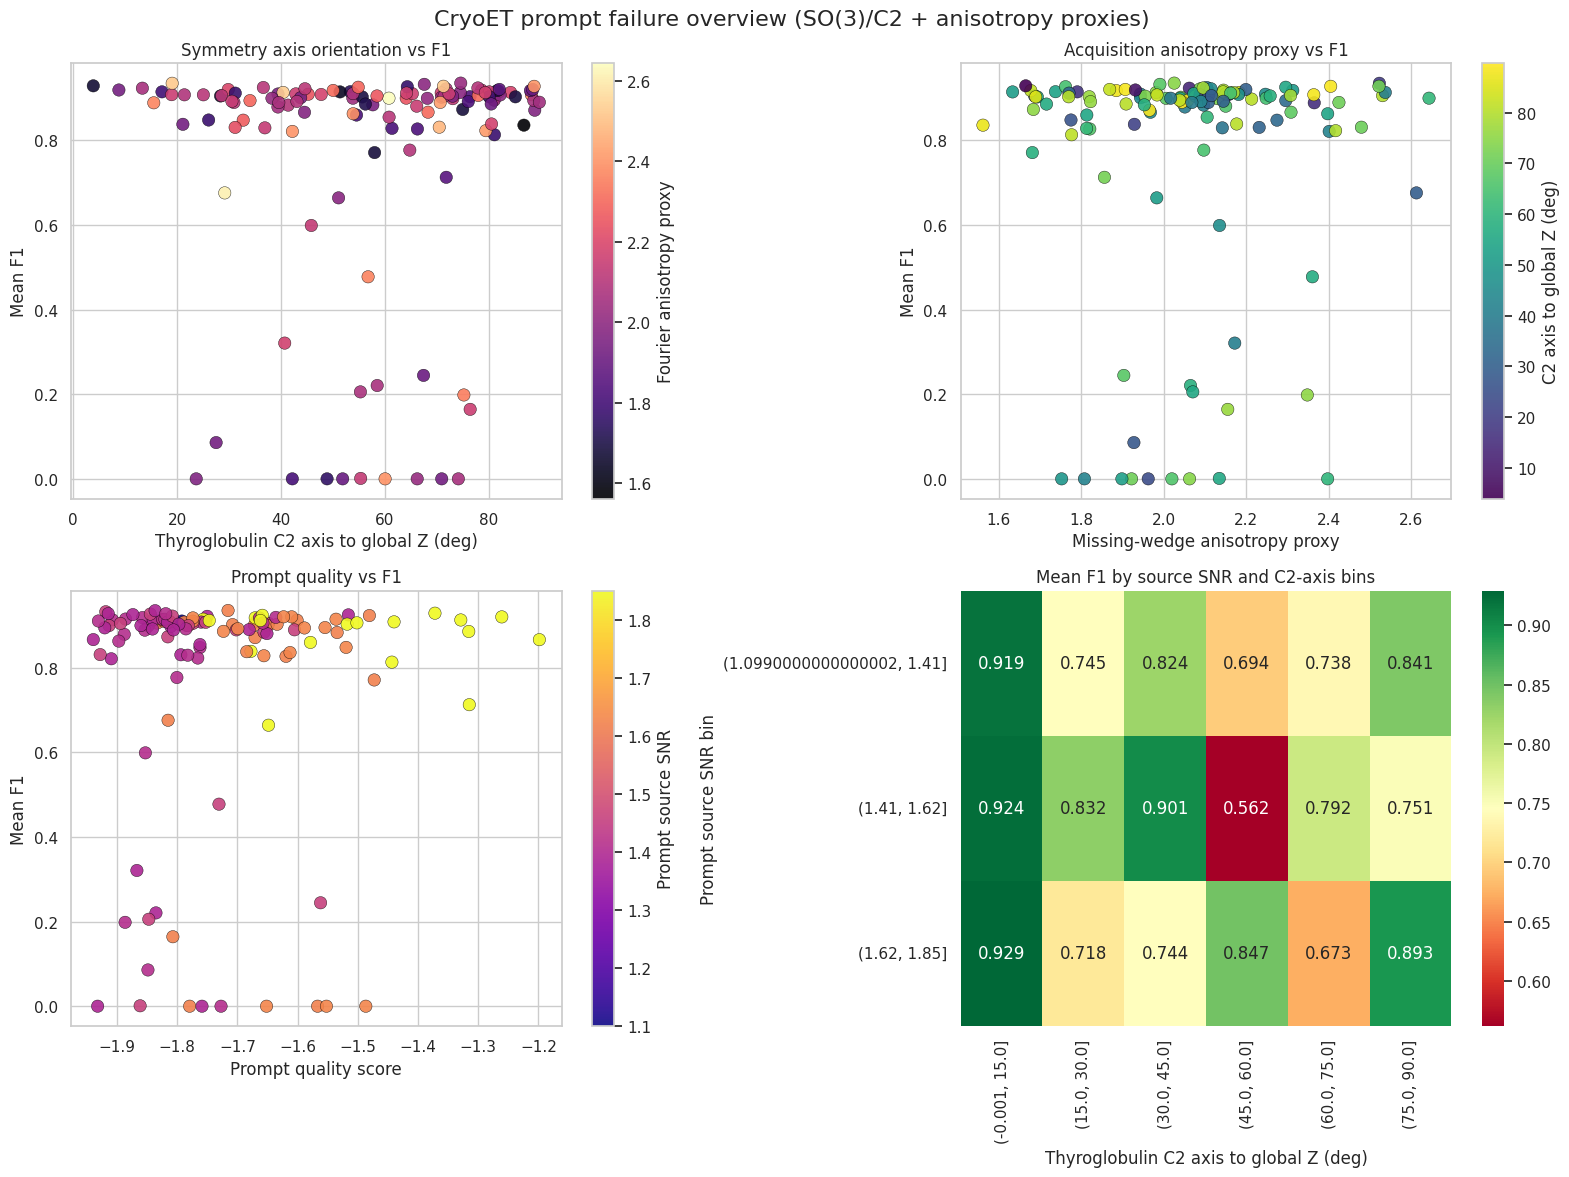

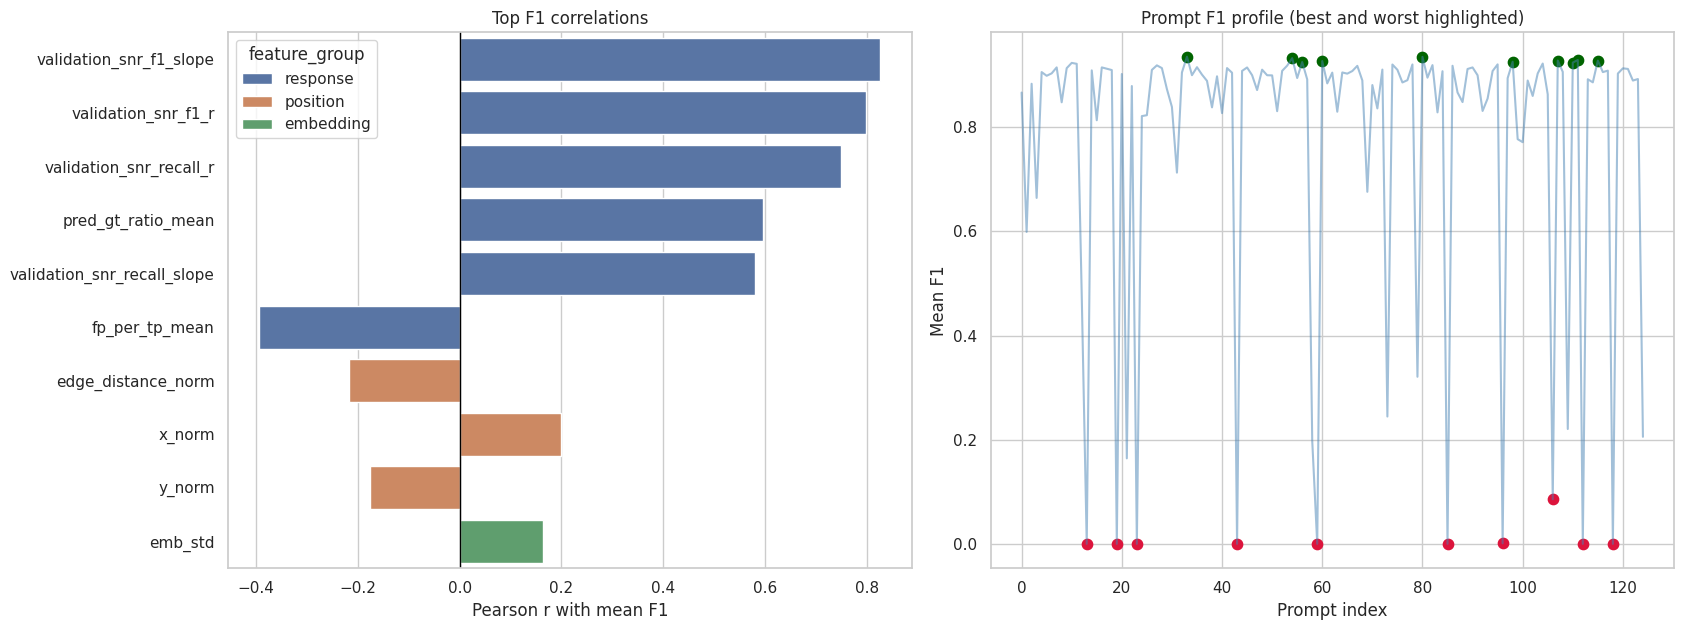

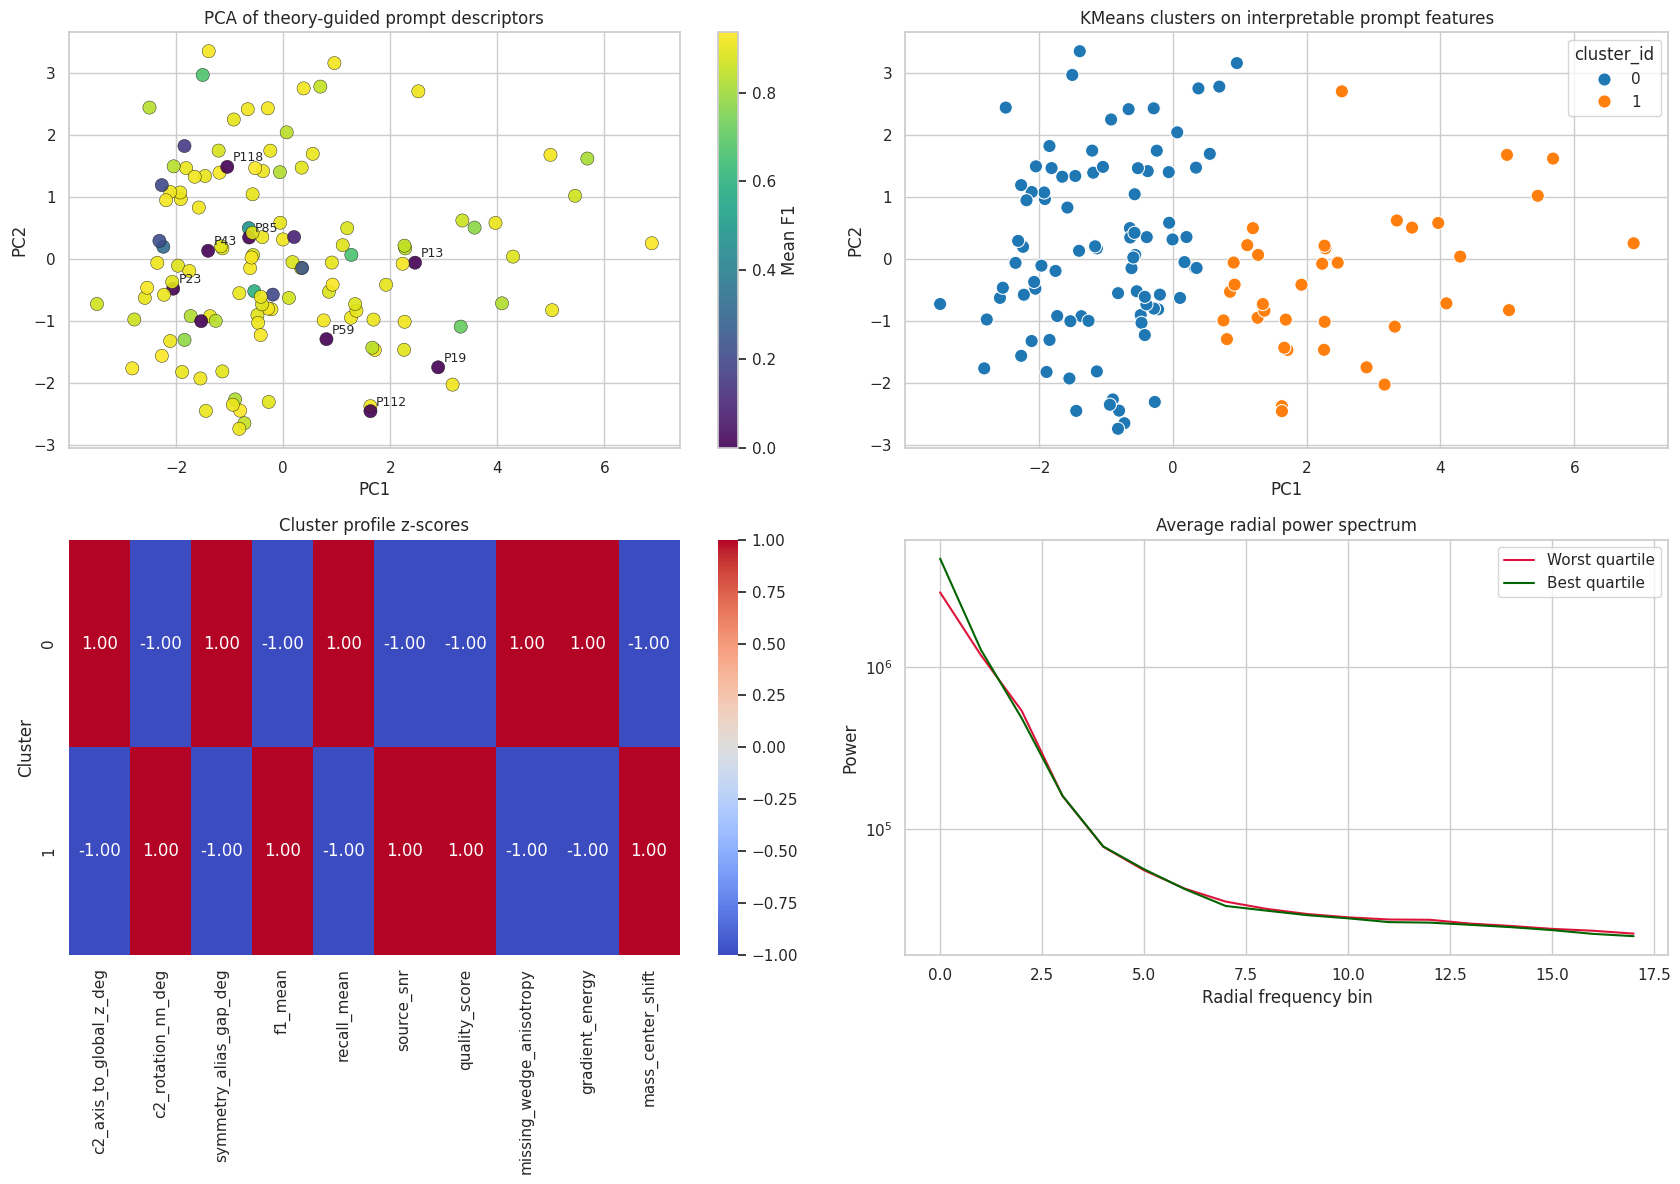

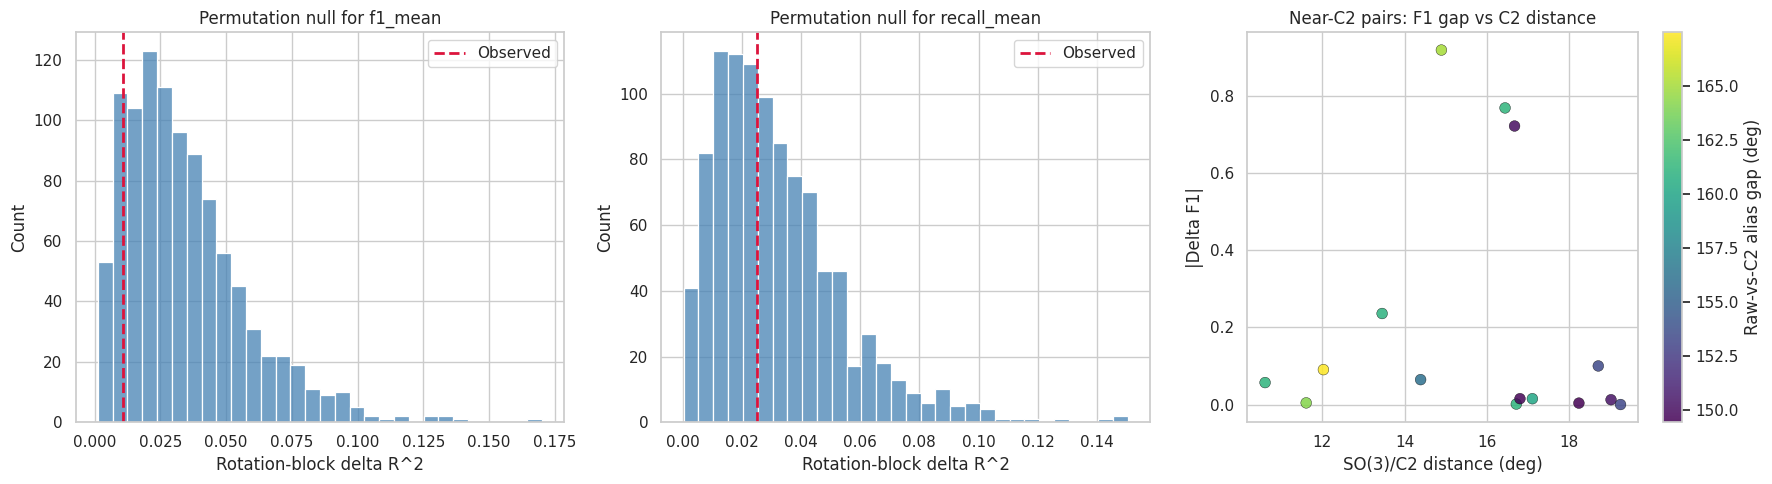

CRYOET THEORY-GUIDED INTERPRETATION
Study subset: 125 prompts (prompt_idx 0..124)
Focus checkpoint: multi_inc16
Main failure signal: mean F1 across the 5 validation tomograms
Secondary safeguard metric: mean recall, so false-negative sensitivity remains visible

Assumptions used in this study:
  - Thyroglobulin is treated as a C2-symmetric particle.
  - The prompt local Z axis is used as a proxy for the thyroglobulin C2 axis.
  - Global Z is used as the acquisition anisotropy axis because tilt-axis metadata is not stored here.
  - missing_wedge_anisotropy is a post-reconstruction Fourier proxy, not the exact acquisition operator.

Top signals by family:
  - Strongest symmetry   signal: c2_neighbour_count_45deg     f1_r=+0.094 (p=0.2982), recall_r=+0.091
  - Strongest acquisition signal: beam_axis_alignment_mean     f1_r=-0.099 (p=0.2718), recall_r=-0.073
  - Strongest quality    signal: power_low                    f1_r=+0.077 (p=0.3932), recall_r=+0.049
  - Strongest position   signal

,prompt_idx,tomo_name,source_snr,f1_mean,recall_mean,c2_axis_to_global_z_deg,c2_rotation_nn_deg,symmetry_alias_gap_deg,quality_score,missing_wedge_anisotropy,z_center_offset_abs,mass_center_shift
13,13,tomo_rec_19_snr1.62,1.62,0.0000,0.0000,60.0557,28.7465,15.0140,-1.5668,2.3978,0.1058,0.1960
19,19,tomo_rec_0_snr1.63,1.63,0.0000,0.0000,23.6890,38.3279,6.1276,-1.4867,1.9624,0.1799,0.4978
23,23,tomo_rec_12_snr1.39,1.39,0.0000,0.0000,70.9538,30.0238,16.5944,-1.9322,1.9220,0.1862,0.2012
43,43,tomo_rec_24_snr1.39,1.39,0.0000,0.0000,66.2382,21.5254,15.4472,-1.7589,2.0198,0.1636,0.2256
59,59,tomo_rec_0_snr1.63,1.63,0.0000,0.0000,74.1619,34.1922,11.8340,-1.6516,2.0628,0.1515,0.3924
85,85,tomo_rec_19_snr1.62,1.62,0.0000,0.0000,48.8808,24.5713,16.8902,-1.7794,1.7523,0.2050,0.2077
112,112,tomo_rec_0_snr1.63,1.63,0.0000,0.0000,42.1931,36.3557,0.0000,-1.5521,1.8076,0.0428,0.2372
118,118,tomo_rec_11_snr1.41,1.41,0.0000,0.0000,51.8811,14.8912,20.7317,-1.7272,1.8985,0.0520,0.2738
96,96,tomo_rec_1_snr1.46,1.46,0.0010,0.0016,55.3497,30.1479,9.1895,-1.8616,2.1349,0.0615,0.2502
106,106,tomo_rec_11_snr1.41,1.41,0.0857,0.0452,27.5196,22.6035,14.6573,-1.8487,1.9276,0.2088,0.5163



Cluster summary:


,cluster_id,f1_mean,recall_mean,c2_axis_to_global_z_deg,c2_rotation_nn_deg,symmetry_alias_gap_deg,source_snr,quality_score,missing_wedge_anisotropy,gradient_energy,mass_center_shift,inertia_anisotropy,z_center_offset_abs,emb_dist_to_centroid,prompt_count
0,0,0.7788,0.7876,57.5304,23.8007,15.7861,1.4793,-1.7901,2.1155,1.6250,0.2333,1.0434,0.1118,0.3593,88
1,1,0.7811,0.7708,57.0302,27.5414,12.5285,1.6792,-1.5444,1.9541,1.5461,0.4241,1.0741,0.0978,0.5686,37



Adjusted rotation/acquisition block:
  - f1_mean: delta_R2=0.0109, partial_R2=0.0120, joint_p=0.8580, perm_p=0.8731
    The rotation + acquisition block does not remain strong after adjustment or permutation control.
  - recall_mean: delta_R2=0.0252, partial_R2=0.0283, joint_p=0.5356, perm_p=0.5475
    The rotation + acquisition block does not remain strong after adjustment or permutation control.

C2 consistency check:
  - Near-C2 pairs (<= 20 deg): n=15, mean |Delta F1|=0.2005, mean |Delta recall|=0.2268
  - Alias-like near-C2 pairs (raw >= 150 deg): mean |Delta F1|=0.2005 vs nan for non-alias near-C2 pairs
    Diagnostic p-values: near-C2 Spearman p=0.1435, alias-vs-nonalias F1 p=nan


In [8]:
import importlib.util

rot_analysis_path = PROJECT_ROOT / "experiments" / "exp4_ppicker_rotations" / "rotational_issues_analysis.py"
spec = importlib.util.spec_from_file_location("exp4_rotational_issues_analysis", rot_analysis_path)
exp4_rotational_issues_analysis = importlib.util.module_from_spec(spec)
spec.loader.exec_module(exp4_rotational_issues_analysis)

analysis_df_selected = globals().get('analysis_df_selected', df_selected if 'df_selected' in globals() else None)
analysis_prompt_info = globals().get('analysis_prompt_info', prompt_info if 'prompt_info' in globals() else None)
analysis_subtomos = globals().get('analysis_subtomos', subtomos if 'subtomos' in globals() else None)
analysis_embeddings = globals().get('analysis_embeddings', embeddings if 'embeddings' in globals() else None)

if len(df_results) == 0:
    print("Skipping rotational issues analysis - run inference first")
elif analysis_prompt_info is None or analysis_subtomos is None or analysis_embeddings is None:
    print("Prompt assets are not loaded. Run the analysis run selection cell first.")
else:
    rotational_issues_analysis = exp4_rotational_issues_analysis.run_rotational_issues_analysis(
        df_selected=analysis_df_selected,
        prompt_info=analysis_prompt_info,
        subtomos=analysis_subtomos,
        embeddings=analysis_embeddings,
        df_results=df_results,
        study_num_prompts=EXP4_STUDY_NUM_PROMPTS,
        results_dir=EXP4_ANALYSIS_RESULTS_DIR,
        tomo_dir=UMU_SYNTH_TOMOS_DIR,
        checkpoint_type="multi",
        increment=16,
        prompt_size=PROMPT_SIZE,
    )

## Step 8: Local-Z Hemisphere Projection on the Rotation Sphere

This view reduces each prompt quaternion to the direction of its local `Z` axis after rotation, so the 125 prompts can be inspected as points on the unit sphere.

Visualization choices:
- `f1_mean` is used as the default prompt-quality metric.
- A configurable threshold splits prompts into `good` (green) and `bad` (red).
- The north and south hemispheres are displayed separately with a Lambert equal-area projection centred on each pole.

This is a directional `S^2` view of the prompt rotations, not a full roll-preserving embedding of `SO(3)`. It is intended to reveal visually coherent groups of prompt orientations that share similar performance.


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.spatial.transform import Rotation

SO3_PROJECTION_METRIC = "f1_mean"
SO3_PROMPT_THRESHOLD = None  # If None, use the median of SO3_PROJECTION_METRIC.
SO3_HIGHER_IS_BETTER = True
SO3_GOOD_COLOR = "#2ca02c"
SO3_BAD_COLOR = "#d62728"
SO3_FIGSIZE = (15, 7)
SO3_LOCAL_Z_AXIS = np.array([0.0, 0.0, 1.0], dtype=float)


def lambert_equal_area_projection(vectors, hemisphere):
    vectors = np.asarray(vectors, dtype=float)
    if vectors.ndim != 2 or vectors.shape[1] != 3:
        raise ValueError("Expected vectors with shape (N, 3).")

    x = vectors[:, 0]
    y = vectors[:, 1]
    z = vectors[:, 2]

    if hemisphere == "north":
        denom = np.sqrt(np.clip(1.0 + z, 1e-8, None))
    elif hemisphere == "south":
        denom = np.sqrt(np.clip(1.0 - z, 1e-8, None))
    else:
        raise ValueError(f"Unsupported hemisphere: {hemisphere}")

    return np.column_stack([x / denom, y / denom])


if "rotational_issues_analysis" in globals() and rotational_issues_analysis is not None:
    so3_analysis_dir = Path(rotational_issues_analysis["analysis_dir"])
    df_so3_source = rotational_issues_analysis["df_prompt_analysis"].copy()
else:
    so3_analysis_dir = Path(EXP4_ANALYSIS_RESULTS_DIR) / f"rotational_issues_analysis_{EXP4_STUDY_NUM_PROMPTS}"
    so3_csv_path = so3_analysis_dir / "prompt_rotational_issue_features.csv"
    if not so3_csv_path.exists():
        raise FileNotFoundError(
            "prompt_rotational_issue_features.csv was not found. Run Step 7 first, or load a saved analysis run."
        )
    df_so3_source = pd.read_csv(so3_csv_path)

required_cols = {"prompt_idx", "q1", "q2", "q3", "q4", SO3_PROJECTION_METRIC}
missing_cols = sorted(required_cols - set(df_so3_source.columns))
if missing_cols:
    raise ValueError(f"Missing required columns for SO(3) sphere projection: {missing_cols}")

quat_array = df_so3_source[["q1", "q2", "q3", "q4"]].to_numpy(dtype=float)
metric_series = pd.to_numeric(df_so3_source[SO3_PROJECTION_METRIC], errors="coerce")
valid_mask = np.isfinite(metric_series.to_numpy()) & np.isfinite(quat_array).all(axis=1)

if not np.all(valid_mask):
    dropped = int((~valid_mask).sum())
    print(f"Dropping {dropped} prompts with invalid quaternion or metric values.")

df_so3 = df_so3_source.loc[valid_mask].copy().reset_index(drop=True)
metric_series = pd.to_numeric(df_so3[SO3_PROJECTION_METRIC], errors="coerce")
quat_array = df_so3[["q1", "q2", "q3", "q4"]].to_numpy(dtype=float)
quat_norms = np.linalg.norm(quat_array, axis=1, keepdims=True)
quat_array = quat_array / np.clip(quat_norms, 1e-8, None)

threshold = float(metric_series.median()) if SO3_PROMPT_THRESHOLD is None else float(SO3_PROMPT_THRESHOLD)
rotations = Rotation.from_quat(quat_array)
z_vectors = rotations.apply(np.repeat(SO3_LOCAL_Z_AXIS[None, :], len(df_so3), axis=0))

df_so3[["sphere_x", "sphere_y", "sphere_z"]] = z_vectors
df_so3["hemisphere"] = np.where(df_so3["sphere_z"] >= 0.0, "north", "south")
if SO3_HIGHER_IS_BETTER:
    df_so3["quality_group"] = np.where(df_so3[SO3_PROJECTION_METRIC] >= threshold, "good", "bad")
else:
    df_so3["quality_group"] = np.where(df_so3[SO3_PROJECTION_METRIC] <= threshold, "good", "bad")

df_so3["proj_x"] = np.nan
df_so3["proj_y"] = np.nan
for hemisphere_name in ["north", "south"]:
    hemi_mask = df_so3["hemisphere"] == hemisphere_name
    if not hemi_mask.any():
        continue
    hemi_vectors = df_so3.loc[hemi_mask, ["sphere_x", "sphere_y", "sphere_z"]].to_numpy(dtype=float)
    hemi_proj = lambert_equal_area_projection(hemi_vectors, hemisphere=hemisphere_name)
    df_so3.loc[hemi_mask, "proj_x"] = hemi_proj[:, 0]
    df_so3.loc[hemi_mask, "proj_y"] = hemi_proj[:, 1]

summary_table = (
    df_so3.groupby(["hemisphere", "quality_group"])
    .agg(
        prompt_count=("prompt_idx", "count"),
        metric_mean=(SO3_PROJECTION_METRIC, "mean"),
        metric_std=(SO3_PROJECTION_METRIC, "std"),
    )
    .reset_index()
    .sort_values(["hemisphere", "quality_group"])
)

print("=" * 90)
print("LOCAL-Z HEMISPHERE PROJECTION")
print("=" * 90)
print(f"Analysis directory: {so3_analysis_dir}")
print(f"Prompts shown: {len(df_so3)}")
print(f"Metric: {SO3_PROJECTION_METRIC}")
print(f"Threshold for good/bad split: {threshold:.4f}")
print("Projection: Lambert equal-area per hemisphere")
display(summary_table.round(4))

display_cols = [
    "prompt_idx",
    SO3_PROJECTION_METRIC,
    "quality_group",
    "hemisphere",
    "sphere_x",
    "sphere_y",
    "sphere_z",
    "proj_x",
    "proj_y",
]
if "tomo_name" in df_so3.columns:
    display_cols.insert(1, "tomo_name")

df_so3_export = df_so3[display_cols].copy()
export_csv_path = so3_analysis_dir / "z_axis_hemisphere_projection.csv"
df_so3_export.to_csv(export_csv_path, index=False)

fig, axes = plt.subplots(1, 2, figsize=SO3_FIGSIZE)
quality_colors = {"good": SO3_GOOD_COLOR, "bad": SO3_BAD_COLOR}

for ax, hemisphere_name, title in zip(
    axes,
    ["north", "south"],
    ["North hemisphere (view centred on +Z)", "South hemisphere (view centred on -Z)"],
):
    hemi_df = df_so3[df_so3["hemisphere"] == hemisphere_name].copy()

    ax.add_patch(Circle((0.0, 0.0), 1.0, fill=False, edgecolor="black", linewidth=1.25))
    ax.axhline(0.0, color="0.8", linewidth=0.8)
    ax.axvline(0.0, color="0.8", linewidth=0.8)

    for quality_name in ["good", "bad"]:
        subset = hemi_df[hemi_df["quality_group"] == quality_name]
        if len(subset) == 0:
            continue
        ax.scatter(
            subset["proj_x"],
            subset["proj_y"],
            s=70,
            alpha=0.88,
            c=quality_colors[quality_name],
            edgecolors="black",
            linewidths=0.35,
            label=f"{quality_name} (n={len(subset)})",
        )

    ax.set_title(f"{title}\nTotal prompts: {len(hemi_df)}")
    ax.set_xlabel("Projected X")
    ax.set_ylabel("Projected Y")
    ax.set_aspect("equal")
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)
    ax.legend(loc="upper right")

fig.suptitle(
    f"Prompt orientation map using rotated local Z axis | {SO3_PROJECTION_METRIC} threshold = {threshold:.4f}",
    fontsize=14,
)
fig.tight_layout()

export_png_path = so3_analysis_dir / "z_axis_hemisphere_projection.png"
fig.savefig(export_png_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved projection table to: {export_csv_path}")
print(f"Saved hemisphere figure to: {export_png_path}")

